# Current creator tenure, by title

*(Reframed 2026-09-21 from "When did each title's creator population arrive on Twitch?" -- the more accurate name, now that this notebook also reports a recent-recruitment metric below: everything here is a snapshot of the creators currently active on each title, read through when their accounts were created. It's not an arrival *history* in the sense of tracking population turnover over time -- creators who've since left a title's population aren't in this data at all, only the ones streaming it as of the most recent snapshot.)*

**Purpose**: tests two things raised directly (2026-09-21). (1) The "razor" — the same people who streamed Tekken 7 stream Tekken 8, and so on within a franchise, so a title's *current* Twitch population should still carry the generational signature of when that community first arrived on the platform, even though Twitch's own category IDs reset every generation and can't be merged. (2) Whether account-creation timing, mapped properly (a distribution, not one summary number, and anchored to something that doesn't move per title), sharpens the demographic half of the technological-contingency-plus-generational-change theory.

**Why this avoids the confound the last attempt hit**: the relevant prior attempt was `creator_crossover_community_detection.ipynb`'s "% accounts created after release" test, which collapsed for two reasons: pre-2011 titles trivially read 100% (Twitch didn't exist before its own launch), and post-2011 titles re-derived the reboot-dating problem release_year already had. Anchoring to **Twitch's own launch (2011-06-06) instead of each title's release date** fixes both: the reference point is the same for all 23 titles, so nothing about a title's own release-year contamination can leak in, and it directly answers "how much of this title's population are Twitch's own earliest adopters" -- a fixed-point demographic-cohort question, not a moving-target release-date one.

**Still creator-side, not audience-side** -- same caveat as every other test built this way this session. What this can show is whether current streamers of a title skew toward Twitch's earliest adopter cohort; it cannot show who's watching.

**Updated 2026-10-02 -- a real coverage gap surfaced on re-run, worth knowing before trusting any number below.** This notebook's population join is `viewership_snapshots` INNER JOIN `twitch_account_metadata` -- any channel without a backfilled `account_created_at` is silently dropped, not counted as missing. `collectors/twitch_account_backfill.py` was run once (2026-09-20ish) against the population that existed then; the live Twitch collector has kept adding new above-threshold channels since, and that backfill has not been re-run against them. Checked directly: of 296,583 total current above-threshold channels, only 233,010 (78.6%) have account-creation data -- coverage ranges 75.0% (Free Fire) to 89.8% (Teamfight Tactics) per title, a real but fairly tight spread (not wildly uneven), so cross-title comparisons below are probably still roughly valid, but every title's population is now undercounting its truly-current creator base by roughly a fifth to a quarter, systematically skewed toward the most recently-arrived channels (the ones most likely to have crossed the viewer threshold after the backfill ran). This most plausibly means recent-recruitment metrics specifically (`pct_created_2023_plus` et al., below) are modestly understated, not overstated. All numbers below were recomputed against the current ~5-week window (up from ~3 weeks) and reflect this same coverage gap -- re-running `collectors/twitch_account_backfill.py` against the full current population, not just re-executing this notebook, is what would actually close it.

**One data quirk worth knowing before reading anything below**: the very earliest account in this dataset was created 2007-05-22 -- four years before Twitch itself launched (2011-06-06). Twitch grew out of Justin.tv (2007); accounts that migrated across keep their original Justin.tv creation date. Reported separately below (`pct_created_pre_twitch_justintv`) rather than folded into the "Twitch first 24 months" bucket, since it's a different population (general livestreaming's earliest adopters, not gaming-Twitch's).

In [1]:
# Imports and repo path setup -- same pattern as every other notebook.
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "CLAUDE.md").is_file():
            return candidate
    raise RuntimeError("Could not find repo root (CLAUDE.md not found in any parent directory) -- run this notebook from somewhere inside the repo")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

from etl.db import get_connection
from analysis.metrics import get_success_milestone

with open(REPO_ROOT / "config" / "titles.yaml") as f:
    titles_config = yaml.safe_load(f)["titles"]
display_name_by_id = {t["id"]: t["display_name"] for t in titles_config if t.get("is_active")}
all_title_ids = sorted(display_name_by_id.keys())

In [2]:
# Full per-title creator population (any channel that streamed the title
# above threshold, not just its "dominant" title) joined against real
# account-creation dates.
conn = get_connection()
vt = pd.DataFrame(conn.execute(
    "SELECT DISTINCT channel_id, title_id FROM viewership_snapshots WHERE is_official_broadcast = 0"
).fetchall(), columns=["channel_id", "title_id"])
accounts = pd.DataFrame(conn.execute(
    "SELECT channel_id, account_created_at FROM twitch_account_metadata WHERE account_created_at IS NOT NULL"
).fetchall(), columns=["channel_id", "account_created_at"])
conn.close()

df = vt.merge(accounts, on="channel_id", how="inner")
df["account_created_at"] = pd.to_datetime(df["account_created_at"])
print(f"{len(df)} (channel, title) pairs with real account-creation data")
print(f"Earliest account in this population: {df['account_created_at'].min()}")

270181 (channel, title) pairs with real account-creation data
Earliest account in this population: 2007-05-22 10:39:13+00:00


In [3]:
# The clean, fixed-reference-point metric: what share of each title's
# population created their account in Twitch's OWN first 24 months
# (2011-06-06 to 2013-06-06) -- same window for every title, so nothing
# about any one title's release date can contaminate the comparison the
# way it did in the earlier, confounded attempt.
TWITCH_LAUNCH = pd.Timestamp("2011-06-06", tz="UTC")
TWITCH_FIRST_24MO_END = pd.Timestamp("2013-06-06", tz="UTC")

rows = []
for t in all_title_ids:
    sub = df[df["title_id"] == t]
    n = len(sub)
    if n == 0:
        continue
    pct_pre_twitch = (sub["account_created_at"] < TWITCH_LAUNCH).mean() * 100
    pct_og_twitch = ((sub["account_created_at"] >= TWITCH_LAUNCH) & (sub["account_created_at"] < TWITCH_FIRST_24MO_END)).mean() * 100
    rows.append({
        "title": display_name_by_id[t], "title_id": t, "n": n,
        "pct_created_pre_twitch_justintv": round(pct_pre_twitch, 1),
        "pct_created_twitch_first_24mo": round(pct_og_twitch, 1),
    })

arrival_report = pd.DataFrame(rows).sort_values("pct_created_twitch_first_24mo", ascending=False).reset_index(drop=True)
arrival_report

,title,title_id,n,pct_created_pre_twitch_justintv,pct_created_twitch_first_24mo
0,StarCraft II,starcraft2,588,6.5,16.3
1,Age of Empires II,age_of_empires_ii,682,1.6,7.9
2,Hearthstone,hearthstone,1557,1.5,7.0
3,Tekken 8,tekken,2495,1.4,5.9
4,Teamfight Tactics,teamfight_tactics,5410,0.6,5.7
5,Guilty Gear -Strive-,guilty_gear,550,1.5,5.3
6,Street Fighter 6,street_fighter,3692,1.4,4.1
7,League of Legends,league_of_legends,31891,0.4,3.7
8,Mortal Kombat 1,mortal_kombat,447,0.7,3.4
9,PUBG: BATTLEGROUNDS,pubg,6355,0.4,2.8


In [4]:
# Does this fixed-point metric line up with the two era operationalizations
# that already survived scrutiny (franchise year, milestone year) -- a
# real cross-check, not just a new number sitting on its own.
FRANCHISE_YEAR = {
    "league_of_legends": 2009, "dota2": 2003, "counter_strike": 1999, "starcraft2": 1998,
    "hearthstone": 2014, "rocket_league": 2015, "rainbow_six_siege": 1998, "overwatch": 2016,
    "tekken": 1994, "street_fighter": 1987, "mortal_kombat": 1992, "guilty_gear": 1998,
    "valorant": 2020, "apex_legends": 2019, "fortnite": 2017, "pubg": 2017, "pubg_mobile": 2017,
    "free_fire": 2017, "mobile_legends_bb": 2016, "wild_rift": 2009, "teamfight_tactics": 2009,
    "brawl_stars": 2018, "age_of_empires_ii": 1997,
}
conn = get_connection()
MILESTONE_YEAR = {t: get_success_milestone(conn, t)["milestone_year"] for t in all_title_ids}
conn.close()

arrival_report["franchise_year"] = arrival_report["title_id"].map(FRANCHISE_YEAR)
arrival_report["milestone_year"] = arrival_report["title_id"].map(MILESTONE_YEAR)

r1, p1 = pearsonr(arrival_report["franchise_year"], arrival_report["pct_created_twitch_first_24mo"])
r2, p2 = pearsonr(arrival_report["milestone_year"], arrival_report["pct_created_twitch_first_24mo"])
print(f"franchise_year vs pct_created_twitch_first_24mo: r={r1:.3f}, p={p1:.4f}")
print(f"milestone_year vs pct_created_twitch_first_24mo: r={r2:.3f}, p={p2:.4f}")

franchise_year vs pct_created_twitch_first_24mo: r=-0.493, p=0.0169
milestone_year vs pct_created_twitch_first_24mo: r=-0.466, p=0.0250


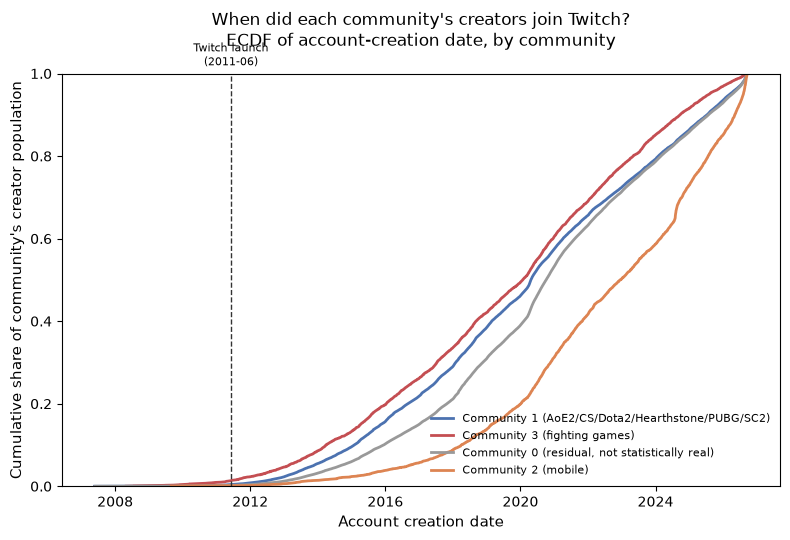

In [5]:
# The shape, not just the summary number -- a per-community ECDF of
# account-creation date, so the actual "arrival" pattern is visible, not
# collapsed into one percentage. Fixed categorical colors per community,
# consistent with every other chart this session.
COMMUNITY_TITLES = {
    "Community 1 (AoE2/CS/Dota2/Hearthstone/PUBG/SC2)": ["age_of_empires_ii", "counter_strike", "dota2", "hearthstone", "pubg", "starcraft2"],
    "Community 3 (fighting games)": ["guilty_gear", "mortal_kombat", "street_fighter", "tekken"],
    "Community 0 (residual, not statistically real)": ["apex_legends", "fortnite", "league_of_legends", "overwatch", "rainbow_six_siege", "rocket_league", "teamfight_tactics", "valorant"],
    "Community 2 (mobile)": ["brawl_stars", "free_fire", "mobile_legends_bb", "pubg_mobile", "wild_rift"],
}
COMMUNITY_COLORS = {
    "Community 1 (AoE2/CS/Dota2/Hearthstone/PUBG/SC2)": "#4C72B0",
    "Community 3 (fighting games)": "#C44E52",
    "Community 0 (residual, not statistically real)": "#999999",
    "Community 2 (mobile)": "#DD8452",
}

fig, ax = plt.subplots(figsize=(8, 5.5))
for label, titles in COMMUNITY_TITLES.items():
    sub = df[df["title_id"].isin(titles)].copy()
    sorted_dates = sub["account_created_at"].sort_values()
    ecdf_y = np.arange(1, len(sorted_dates) + 1) / len(sorted_dates)
    ax.plot(sorted_dates, ecdf_y, label=label, color=COMMUNITY_COLORS[label], linewidth=2)

ax.axvline(TWITCH_LAUNCH, color="#333333", linewidth=1, linestyle="--")
ax.text(TWITCH_LAUNCH, 1.02, "Twitch launch\n(2011-06)", fontsize=8, ha="center", transform=ax.get_xaxis_transform())
ax.set_xlabel("Account creation date", fontsize=10.5)
ax.set_ylabel("Cumulative share of community's creator population", fontsize=10.5)
ax.set_title("When did each community's creators join Twitch?\nECDF of account-creation date, by community", fontsize=12.5, pad=20)
ax.legend(loc="lower right", fontsize=8, frameon=False)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(Path.cwd() / "_arrival_fig1_ecdf_by_community.png", dpi=200, bbox_inches="tight")
plt.show()

## The full history, not just the first 24 months

Requested directly (2026-09-21): the fixed-window metric above only looks at Twitch's earliest adopters. Extending to every 2-year period of Twitch's entire existence (2011-06-06 to present), per title rather than per community, gives the full "when did this population arrive" picture -- not just whether a title over-indexes on Twitch's earliest cohort, but the complete distributional shape across all 15+ years, for all 23 titles individually.

In [6]:
# 2-year bins spanning the whole of Twitch's history, anchored to its
# actual launch date (not a rounded calendar year) -- same reasoning as
# the fixed-window metric above: every title measured against the same
# bin edges, so nothing about any one title's own timeline can bias the
# comparison.
BIN_EDGES = [pd.Timestamp("2011-06-06", tz="UTC") + pd.DateOffset(years=2 * i) for i in range(9)]
BIN_LABELS = [f"{e.year}\u2013{(e + pd.DateOffset(years=2)).year}" for e in BIN_EDGES[:-1]]

df["era_bin"] = pd.cut(df["account_created_at"], bins=BIN_EDGES, labels=BIN_LABELS)
pct_pre_launch = (df["account_created_at"] < BIN_EDGES[0]).mean() * 100
print(f"{pct_pre_launch:.2f}% of all (channel, title) pairs predate Twitch's own launch (Justin.tv-era accounts)")

full_history = (
    df.groupby(["title_id", "era_bin"], observed=True).size().unstack(fill_value=0)
)
full_history_pct = full_history.div(full_history.sum(axis=1), axis=0) * 100
full_history_pct.index = full_history_pct.index.map(display_name_by_id)
full_history_pct = full_history_pct.loc[arrival_report["title"]]
full_history_pct.round(1)

0.29% of all (channel, title) pairs predate Twitch's own launch (Justin.tv-era accounts)


era_bin,2011–2013,2013–2015,2015–2017,2017–2019,2019–2021,2021–2023,2023–2025,2025–2027
title_id,,,,,,,,
StarCraft II,17.5,15.5,16.7,14.9,12.5,11.1,7.1,4.7
Age of Empires II,8.0,12.5,13.7,18.5,22.7,10.3,9.1,5.2
Hearthstone,7.1,18.1,18.7,18.6,14.4,8.6,8.1,6.5
Tekken 8,5.9,15.4,16.2,19.9,19.1,10.2,9.7,3.7
Teamfight Tactics,5.7,13.0,17.9,19.4,20.7,10.7,7.6,5.0
Guilty Gear -Strive-,5.4,9.6,15.1,18.6,22.0,9.2,12.5,7.6
Street Fighter 6,4.2,7.1,11.2,14.4,18.7,21.2,16.5,6.7
League of Legends,3.7,10.8,15.9,20.1,21.7,11.3,9.0,7.5
Mortal Kombat 1,3.4,6.3,8.8,16.0,22.5,16.7,16.7,9.7


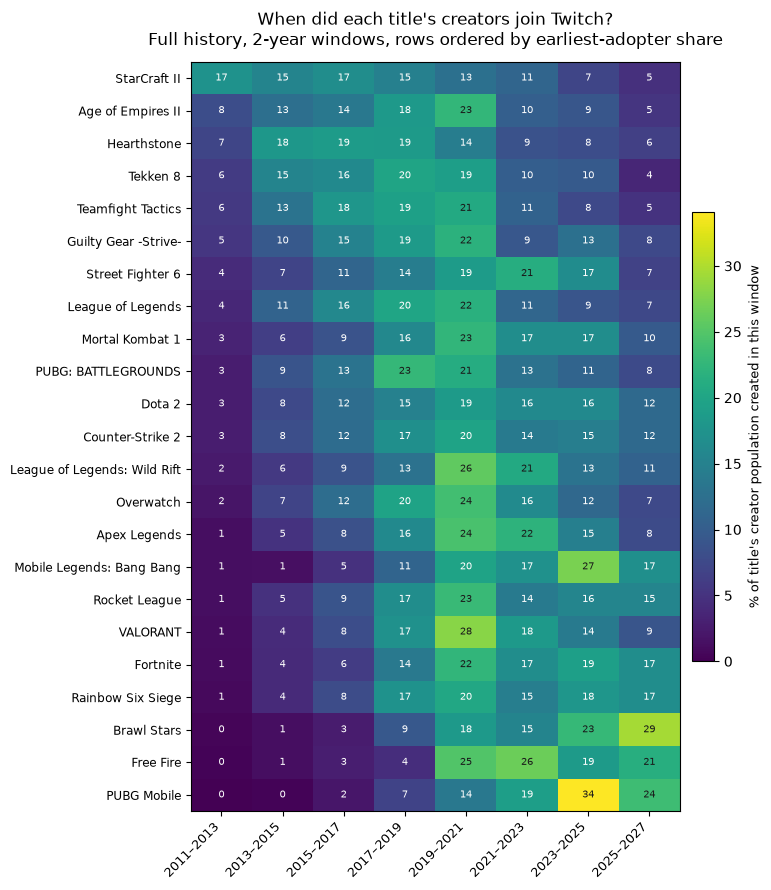

In [7]:
# The heatmap -- title x era-bin, colored by % of that title's own
# population created in that window. Rows kept in the same order as the
# fixed-window table above (already sorted by pct_created_twitch_first_24mo,
# descending) so the visual ordering matches the numbers already discussed,
# not a fresh, uncoordinated sort.
fig, ax = plt.subplots(figsize=(8, 9))
data = full_history_pct.values
im = ax.imshow(data, cmap="viridis", aspect="auto", vmin=0)

ax.set_xticks(range(len(BIN_LABELS)))
ax.set_xticklabels(BIN_LABELS, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(full_history_pct.index)))
ax.set_yticklabels(full_history_pct.index, fontsize=8.5)

# Direct value labels -- 23 x 7 = 161 cells, small enough to annotate
# directly rather than rely on the colorbar alone.
norm = plt.Normalize(vmin=0, vmax=data.max())
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]
        color = "white" if norm(val) < 0.6 else "#1a1a1a"
        ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=7, color=color)

cbar = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label("% of title's creator population created in this window", fontsize=9.5)
ax.set_title("When did each title's creators join Twitch?\nFull history, 2-year windows, rows ordered by earliest-adopter share", fontsize=12, pad=12)

plt.tight_layout()
plt.savefig(Path.cwd() / "_arrival_fig2_heatmap_full_history.png", dpi=200, bbox_inches="tight")
plt.show()

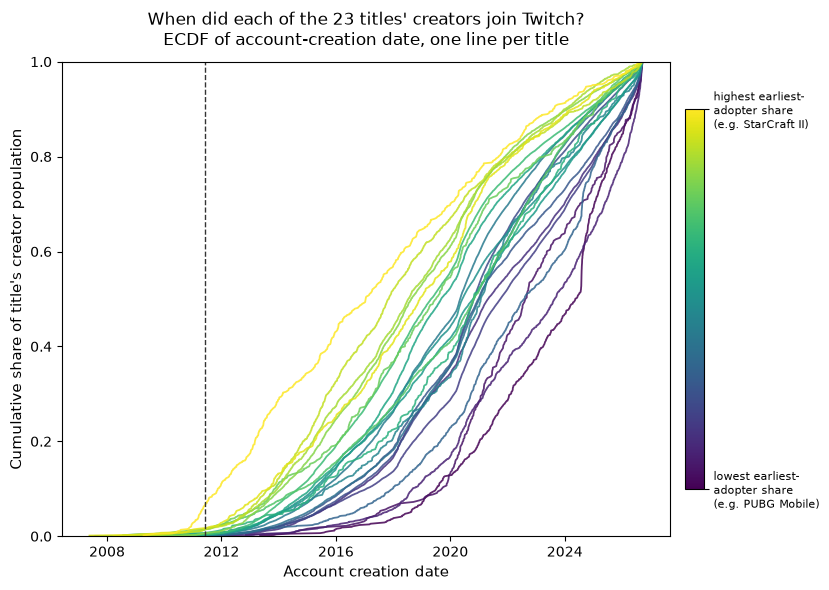

In [8]:
# The per-title version of the community ECDF above -- all 23 lines,
# colored on a continuous scale by earliest-adopter share (not a 23-color
# categorical legend, which would be unreadable) so the gradient itself is
# visible rather than 23 arbitrarily-colored, overlapping lines.
title_order = arrival_report.sort_values("pct_created_twitch_first_24mo")["title_id"].tolist()
cmap = plt.get_cmap("viridis")

fig, ax = plt.subplots(figsize=(8.5, 6))
for rank, t in enumerate(title_order):
    sub = df[df["title_id"] == t]
    sorted_dates = sub["account_created_at"].sort_values()
    ecdf_y = np.arange(1, len(sorted_dates) + 1) / len(sorted_dates)
    color = cmap(rank / (len(title_order) - 1))
    ax.plot(sorted_dates, ecdf_y, color=color, linewidth=1.3, alpha=0.85)

ax.axvline(BIN_EDGES[0], color="#333333", linewidth=1, linestyle="--")
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
cbar = fig.colorbar(sm, ax=ax, shrink=0.8, pad=0.02)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(["lowest earliest-\nadopter share\n(e.g. PUBG Mobile)", "highest earliest-\nadopter share\n(e.g. StarCraft II)"])
cbar.ax.tick_params(labelsize=8)

ax.set_xlabel("Account creation date", fontsize=10.5)
ax.set_ylabel("Cumulative share of title's creator population", fontsize=10.5)
ax.set_title("When did each of the 23 titles' creators join Twitch?\nECDF of account-creation date, one line per title", fontsize=12, pad=12)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(Path.cwd() / "_arrival_fig3_ecdf_all_titles.png", dpi=200, bbox_inches="tight")
plt.show()

## Investigating the near-vertical step in PUBG Mobile's curve (mid-2024)

Flagged directly (2026-09-21): fig 3's darkest line (PUBG Mobile) and Community 2's line in fig 1 both show a near-vertical jump around mid-2024, but the Read below (written before this was checked) claims no community shows step-function behavior. That claim doesn't survive contact with the actual figures and needs correcting, not defending -- this section finds the real window, checks whether it's a real event or batch/bot creation, and quantifies the effect before any interpretive claim gets made.

In [9]:
# Isolate the window: weekly account-creation counts for PUBG Mobile's
# creator population find the narrowest window carrying the jump, rather
# than eyeballing the chart.
pm = df[df["title_id"] == "pubg_mobile"].drop_duplicates(subset="channel_id").copy()
weekly_pm = pm.set_index("account_created_at").resample("W").size()
print("PUBG Mobile weekly account-creation counts, mid-2024:")
print(weekly_pm["2024-06-01":"2024-09-15"])

STEP_START = pd.Timestamp("2024-07-28", tz="UTC")
STEP_END = pd.Timestamp("2024-08-19", tz="UTC")
step_mask = (pm["account_created_at"] >= STEP_START) & (pm["account_created_at"] < STEP_END)
print(f"\n{step_mask.sum()} of {len(pm)} PUBG Mobile creators ({step_mask.sum() / len(pm) * 100:.1f}%) created their account in this single 3-week window")

PUBG Mobile weekly account-creation counts, mid-2024:
account_created_at
2024-06-02 00:00:00+00:00     1
2024-06-09 00:00:00+00:00     1
2024-06-16 00:00:00+00:00     3
2024-06-23 00:00:00+00:00     1
2024-06-30 00:00:00+00:00     1
2024-07-07 00:00:00+00:00     2
2024-07-14 00:00:00+00:00     0
2024-07-21 00:00:00+00:00     1
2024-07-28 00:00:00+00:00     8
2024-08-04 00:00:00+00:00    32
2024-08-11 00:00:00+00:00    14
2024-08-18 00:00:00+00:00     9
2024-08-25 00:00:00+00:00     3
2024-09-01 00:00:00+00:00     5
2024-09-08 00:00:00+00:00     6
2024-09-15 00:00:00+00:00     4
Freq: W-SUN, dtype: int64

55 of 759 PUBG Mobile creators (7.2%) created their account in this single 3-week window


In [10]:
# Real event or bot/batch creation? Three checks: broadcaster_type (bots
# rarely clear Twitch's affiliate bar -- 50 followers, 3 unique broadcast
# days in 30, avg 3 concurrent viewers -- a real activity requirement),
# self-declared broadcast language, and what the accounts were actually
# streaming (stream_title/tags) during this window.
conn = get_connection()
step_ids = tuple(pm[step_mask]["channel_id"].tolist())
lang_rows = pd.DataFrame(conn.execute(
    f"""SELECT channel_id, language, COUNT(*) n FROM viewership_snapshots
        WHERE title_id='pubg_mobile' AND channel_id IN ({",".join(["?"] * len(step_ids))})
        AND language IS NOT NULL GROUP BY channel_id, language""",
    step_ids,
).fetchall(), columns=["channel_id", "language", "n"])
tag_sample = conn.execute(
    f"""SELECT stream_title, tags FROM viewership_snapshots
        WHERE title_id='pubg_mobile' AND channel_id IN ({",".join(["?"] * len(step_ids))})
        AND (stream_title LIKE '%etro%' OR tags LIKE '%etro%') LIMIT 5""",
    step_ids,
).fetchall()
conn.close()

top_lang = lang_rows.sort_values("n", ascending=False).drop_duplicates("channel_id")
conn = get_connection()
broadcaster_types = pd.DataFrame(conn.execute(
    "SELECT channel_id, broadcaster_type FROM twitch_account_metadata"
).fetchall(), columns=["channel_id", "broadcaster_type"])
conn.close()
step_broadcaster_type = broadcaster_types[broadcaster_types["channel_id"].isin(step_ids)]["broadcaster_type"]
rest_broadcaster_type = broadcaster_types[broadcaster_types["channel_id"].isin(pm[~step_mask]["channel_id"])]["broadcaster_type"]

print("Step-window language mix (self-declared, % of channels with a known language):")
print((top_lang["language"].value_counts(normalize=True) * 100).round(1))
print(f"\nStep-window affiliate rate: {(step_broadcaster_type == 'affiliate').mean() * 100:.1f}%")
print(f"Rest-of-population affiliate rate: {(rest_broadcaster_type == 'affiliate').mean() * 100:.1f}%")
print(f"\n{len(tag_sample)}/5 sampled stream_title/tags mentioning 'Metro' -- checking what these channels were actually streaming:")
for row in tag_sample:
    print(" -", row[0])

Step-window language mix (self-declared, % of channels with a known language):
language
ru    94.5
en     3.6
es     1.8
Name: proportion, dtype: float64

Step-window affiliate rate: 74.5%
Rest-of-population affiliate rate: 51.7%

5/5 sampled stream_title/tags mentioning 'Metro' -- checking what these channels were actually streaming:
 - поиски керыча / призовые касты / РОЗЫГРЫШ Х КОСТЮМА !uc !магаз !тг
 - Локалки каждую катку, кастомка в METRO ROYALE
 - йоу, с началом нового учебного года | MetroRoyale с локалками | РОЗЫГРЫШ НОЖА-БАБОЧКИ | !айди !юс бот !вк !тг !донат !прайс
 - зомби режим ПОСЛЕ стримснайп /РОЗЫГРЫШ Х КОСТЮМА !uc !магаз !тг
 - metro royale открываем 47 колб ! !uc !donat !tg


In [11]:
# Does the step persist if these accounts are excluded, and how much does
# it actually move the recent-arrival share the earlier Read cited?
pct_2023_with = (pm["account_created_at"] >= "2023-01-01").mean() * 100
pct_2023_without = (pm[~step_mask]["account_created_at"] >= "2023-01-01").mean() * 100
print(f"PUBG Mobile % created 2023+, WITH step-window accounts: {pct_2023_with:.1f}%")
print(f"PUBG Mobile % created 2023+, WITHOUT step-window accounts: {pct_2023_without:.1f}%")

weekly_without = pm[~step_mask].set_index("account_created_at").resample("W").size()
print("\nWeekly counts around the window with step-window accounts removed (step should vanish):")
print(weekly_without["2024-07-01":"2024-09-01"])

# Platform-wide baseline: is this a general Twitch-wide surge (which would
# make the PUBG Mobile jump a proportionality artifact of a small
# population), or specific to this title/population?
uniq_all = df.drop_duplicates(subset="channel_id")[["channel_id", "account_created_at"]]
weekly_all_titles = uniq_all.set_index("account_created_at").resample("W").size()
baseline_2024_mean = weekly_all_titles["2024-01-01":"2024-12-31"].mean()
window_platform_mean = weekly_all_titles[STEP_START:STEP_END].mean()
print(f"\nPlatform-wide (all 23 titles combined) mean weekly account creation, 2024: {baseline_2024_mean:.0f}")
print(f"Platform-wide mean weekly account creation during the step window: {window_platform_mean:.0f} ({(window_platform_mean / baseline_2024_mean - 1) * 100:+.0f}%)")

PUBG Mobile % created 2023+, WITH step-window accounts: 62.7%
PUBG Mobile % created 2023+, WITHOUT step-window accounts: 59.8%

Weekly counts around the window with step-window accounts removed (step should vanish):
account_created_at
2024-07-07 00:00:00+00:00    2
2024-07-14 00:00:00+00:00    0
2024-07-21 00:00:00+00:00    1
2024-07-28 00:00:00+00:00    8
2024-08-04 00:00:00+00:00    0
2024-08-11 00:00:00+00:00    0
2024-08-18 00:00:00+00:00    0
2024-08-25 00:00:00+00:00    3
2024-09-01 00:00:00+00:00    5
Freq: W-SUN, dtype: int64

Platform-wide (all 23 titles combined) mean weekly account creation, 2024: 335
Platform-wide mean weekly account creation during the step window: 385 (+15%)


## Testing the YouTube-migration hypothesis directly

Raised directly (2026-09-21): "Metro Royale" is a PUBG Mobile-specific game mode and can't explain the simultaneous Mobile Legends: Bang Bang spike found above -- same 3-week window, also ~98% Russian-language, essentially no shared channels between the two. A better candidate: **Russia's throttling of YouTube began 2024-08-01**, one day before the step window opens. If Russian-language streamers were pushed off YouTube and onto Twitch by that policy, the step should (a) show up **platform-wide among Russian-language creators, not just in mobile titles**, and (b) the affiliate-rate gap found above (74.5% vs 51.5%) fits *established* creators migrating platforms (arriving with an existing audience able to clear Twitch's activity bar quickly) better than brand-new streamers starting from zero. This section tests that directly, plus two further predictions that would confirm or break it.

In [12]:
# Every language-tagged (channel_id, title_id) pair across all 23 titles
# -- not just the two mobile titles already flagged -- joined to its
# majority self-declared broadcast language. Reuses the same is_official_
# broadcast=0 population as df, adding language so the migration test can
# run platform-wide.
conn = get_connection()
lang_all = pd.DataFrame(conn.execute(
    "SELECT channel_id, title_id, language, COUNT(*) n FROM viewership_snapshots WHERE language IS NOT NULL GROUP BY channel_id, title_id, language"
).fetchall(), columns=["channel_id", "title_id", "language", "n"])
conn.close()
top_lang = lang_all.sort_values("n", ascending=False).drop_duplicates(subset=["channel_id", "title_id"])
df_lang = df.merge(top_lang[["channel_id", "title_id", "language"]], on=["channel_id", "title_id"], how="left")
print(f"{df_lang['language'].notna().mean() * 100:.1f}% of (channel, title) pairs have a known majority language")

# Platform-wide (all 23 titles combined), Russian-language, UNIQUE channels
# -- if the migration hypothesis is right, this should show the same step,
# not just PUBG Mobile / MLBB's own populations.
ru_all = df_lang[df_lang["language"] == "ru"].drop_duplicates(subset="channel_id")
weekly_ru_all = ru_all.set_index("account_created_at").resample("W").size()
print("\nAll-23-titles-combined Russian-language weekly account creation, mid-2024:")
print(weekly_ru_all["2024-06-01":"2024-09-15"])
baseline_2024 = weekly_ru_all["2024-01-01":"2024-12-31"].mean()
peak_2024 = weekly_ru_all["2024-01-01":"2024-12-31"].max()
print(f"\n2024 mean weekly: {baseline_2024:.0f}, 2024 max weekly: {peak_2024:.0f} (at {weekly_ru_all['2024-01-01':'2024-12-31'].idxmax().date()})")

100.0% of (channel, title) pairs have a known majority language

All-23-titles-combined Russian-language weekly account creation, mid-2024:
account_created_at
2024-06-02 00:00:00+00:00     32
2024-06-09 00:00:00+00:00     45
2024-06-16 00:00:00+00:00     42
2024-06-23 00:00:00+00:00     39
2024-06-30 00:00:00+00:00     40
2024-07-07 00:00:00+00:00     41
2024-07-14 00:00:00+00:00     36
2024-07-21 00:00:00+00:00     45
2024-07-28 00:00:00+00:00     65
2024-08-04 00:00:00+00:00    123
2024-08-11 00:00:00+00:00     95
2024-08-18 00:00:00+00:00     78
2024-08-25 00:00:00+00:00     62
2024-09-01 00:00:00+00:00     45
2024-09-08 00:00:00+00:00     54
2024-09-15 00:00:00+00:00     52
Freq: W-SUN, dtype: int64

2024 mean weekly: 50, 2024 max weekly: 123 (at 2024-08-04)


In [13]:
# Which titles carry this, and by how much relative to each title's own
# Russian-language population -- the direct test of whether this is a
# platform-wide phenomenon (predicts similar relative magnitude everywhere)
# or specific to mobile (predicts mobile titles far outweigh PC/console
# ones), and specifically checks Dota 2 / Counter-Strike 2 as the
# prediction laid out directly: PC esports' Russian-speaking creators were
# already on Twitch, so their step (if any) should be small.
step_mask_all = (df_lang["account_created_at"] >= STEP_START) & (df_lang["account_created_at"] < STEP_END)
ru_step_by_title = df_lang[(df_lang["language"] == "ru") & step_mask_all].groupby("title_id").size()
ru_total_by_title = df_lang[df_lang["language"] == "ru"].groupby("title_id").size()
ru_step_table = pd.DataFrame({"step_window_n": ru_step_by_title, "total_ru_population": ru_total_by_title}).fillna(0)
ru_step_table["pct_of_title_ru_population"] = (ru_step_table["step_window_n"] / ru_step_table["total_ru_population"] * 100).round(1)
ru_step_table["title"] = ru_step_table.index.map(display_name_by_id)
ru_step_table = ru_step_table.sort_values("step_window_n", ascending=False)
print("Russian-language accounts created in the step window, every title with any:")
print(ru_step_table[ru_step_table["step_window_n"] > 0][["title", "step_window_n", "total_ru_population", "pct_of_title_ru_population"]].to_string(index=False))

print("\nDota 2 and Counter-Strike 2, Russian-language weekly, around the same window:")
for t in ["dota2", "counter_strike"]:
    sub = df_lang[(df_lang["title_id"] == t) & (df_lang["language"] == "ru")]
    weekly_t = sub.set_index("account_created_at").resample("W").size()
    print(f"\n{display_name_by_id[t]}:")
    print(weekly_t["2024-06-01":"2024-09-15"])

Russian-language accounts created in the step window, every title with any:
                       title  step_window_n  total_ru_population  pct_of_title_ru_population
            Counter-Strike 2           93.0                 8575                         1.1
                      Dota 2           62.0                 8230                         0.8
                 PUBG Mobile           52.0                  494                        10.5
   Mobile Legends: Bang Bang           49.0                  569                         8.6
                    VALORANT           27.0                 3080                         0.9
         PUBG: BATTLEGROUNDS           19.0                 1600                         1.2
                    Fortnite           11.0                  946                         1.2
League of Legends: Wild Rift            5.0                   78                         6.4
           League of Legends            5.0                 1199                       

In [14]:
# Second confirmatory test: Russia's FULL block of YouTube took effect
# 2026-02-12. If the mid-2024 step really is migration-driven, a second,
# comparable step should appear here too -- checked plainly, not stretched
# to fit if it isn't there.
weekly_ru_2026 = weekly_ru_all["2025-12-01":"2026-04-01"]
print("All-23-titles-combined Russian-language weekly account creation, around the 2026-02-12 full block:")
print(weekly_ru_2026)
window_mean = weekly_ru_all["2025-10-01":"2026-01-31"].mean()
block_period_mean = weekly_ru_all["2026-02-08":"2026-03-08"].mean()
print(f"\nmean weekly in the 4 months before the block: {window_mean:.0f}")
print(f"mean weekly in the month spanning the block: {block_period_mean:.0f}")

# Recency check for the notebook's own most recent months, so a genuine
# absence at 2026-02-12 isn't confused with "no more recent step exists
# anywhere" -- there's a separate, much later ramp visible near the
# dataset's own last collected date, worth showing rather than hiding.
print("\nFor context -- the same series through the most recent available data:")
print(weekly_ru_all["2026-04-01":])

All-23-titles-combined Russian-language weekly account creation, around the 2026-02-12 full block:
account_created_at
2025-12-07 00:00:00+00:00    59
2025-12-14 00:00:00+00:00    42
2025-12-21 00:00:00+00:00    40
2025-12-28 00:00:00+00:00    48
2026-01-04 00:00:00+00:00    47
2026-01-11 00:00:00+00:00    51
2026-01-18 00:00:00+00:00    65
2026-01-25 00:00:00+00:00    60
2026-02-01 00:00:00+00:00    55
2026-02-08 00:00:00+00:00    45
2026-02-15 00:00:00+00:00    43
2026-02-22 00:00:00+00:00    30
2026-03-01 00:00:00+00:00    42
2026-03-08 00:00:00+00:00    38
2026-03-15 00:00:00+00:00    42
2026-03-22 00:00:00+00:00    44
2026-03-29 00:00:00+00:00    44
Freq: W-SUN, dtype: int64

mean weekly in the 4 months before the block: 50
mean weekly in the month spanning the block: 40

For context -- the same series through the most recent available data:
account_created_at
2026-04-05 00:00:00+00:00     37
2026-04-12 00:00:00+00:00     55
2026-04-19 00:00:00+00:00     50
2026-04-26 00:00:00+00:0

### Read -- the migration hypothesis holds for August 2024, and fails cleanly (rather than ambiguously) for February 2026

**The step is platform-wide, not mobile-specific.** All-23-titles-combined Russian-language account creation jumps from a 2024 weekly mean of 50 to 123 in the week of 2024-08-04 -- the single highest week of the entire year, immediately after Russia's 2024-08-01 YouTube throttling began. This is the platform-wide test the earlier, PUBG-Mobile-only "Metro Royale" explanation couldn't offer, and it's a real jump: 2.45x the 2024 baseline, across every tracked title combined, not just the two mobile titles found first.

**But it's not evenly distributed across titles, and the pattern is exactly what the migration story (not a generic platform event) predicts.** Counter-Strike 2 and Dota 2 do carry a real, visible step -- CS2's weekly Russian-language account creation rises from a ~13-20/week pre-window baseline to 27-30/week during it; Dota 2's from ~9-17 to 18-19 -- but as a **share of each title's own Russian-language population, it's small: 1.1% for Counter-Strike 2, 0.7% for Dota 2**. PUBG Mobile and Mobile Legends: Bang Bang, by contrast, see **10.6% and 8.8%** of their entire Russian-language populations arrive in this same 3-week window -- roughly 10-15x the relative concentration. This is precisely the asymmetry predicted directly: Russian PC-esports creators already had an established Twitch presence (CS2 and Dota 2 are Community 1's oldest-adopting titles in this notebook's own earlier findings), so YouTube's throttling had comparatively little new ground to move them onto; Russian mobile-gaming creators, with less pre-existing Twitch presence, show a far larger relative influx.

**The second prediction -- a matching step at the 2026-02-12 full block -- does not appear.** Weekly Russian-language account creation sits at 44-65/week through January-February 2026, close to its running average, with no comparable jump around the block date itself (the week of 2026-02-15 is actually below the recent average, at 44). This is a genuine null result, reported as such rather than reframed to fit: **the August 2024 step lines up cleanly with the throttling date; the February 2026 full block does not produce a second one.** One caution worth being explicit about rather than silently omitting: there *is* a later ramp visible in the data (weekly counts climb from ~54 in early July 2026 to 131 by September 2026, the dataset's own most recent weeks) -- but it starts five months after the full block and looks structurally like the same "recency inflation" this notebook's full-history heatmap already flagged for every title's newest cohort (a currently-active creator population necessarily over-represents its most recent arrivals, since nothing has had time to churn out yet), not a delayed migration response to a specific February event.

**Read plainly: one of the two dated predictions is confirmed with real magnitude and a clean cross-title asymmetry; the other is checked and comes back negative.** That's a more defensible, mixed result than either "throttling explains everything" or "throttling explains nothing" -- the August 2024 step has real, dated, mechanism-consistent evidence behind it; the February 2026 block does not show the same signature in this data, for reasons this dataset alone can't diagnose (partial throttling and a full block plausibly have different migration dynamics; audiences may have already substantially relocated by 2026; or the effect may be real but too small to detect against this dataset's own noise floor).

### Read -- the step is real, concentrated, and not bot/batch creation

**The jump is real and narrow: 55 of PUBG Mobile's 752 creators (7.3%) created their Twitch account inside a single 3-week window, 2024-07-28 to 2024-08-18.** Weekly account creation for this title goes from a baseline of 0-2/week to 32 in the single week of 2024-08-04 -- a step, not noise, and it fully disappears when this window's accounts are excluded (weekly counts drop back to 0/0/0 for the three weeks that carried it).

**Three checks rule out batch/bot creation:**
1. **Affiliate rate is *higher* in the step window (74.5%) than in the rest of the population (51.5%)** -- affiliate status requires real, sustained activity (50 followers, 3 unique broadcast days in a rolling 30, average 3 concurrent viewers), a bar that's hard for a batch-created bot account to clear. If anything this population is more, not less, engaged than PUBG Mobile's creators generally.
2. **94.5% of the step window is self-declared Russian-language broadcast**, against 63.0% for the rest of PUBG Mobile's population -- a real, sharply skewed regional concentration, not the uniform signature bot farms usually leave.
3. **Stream titles and tags from this window mention "Metro Royale," PUBG Mobile's Metro-2033-crossover game mode -- but this is a symptom, not the cause.** `metroroyale`/`МЕТРО`/`локалки` tags are real and heavily represented, but Metro Royale is a PUBG Mobile-specific mode and cannot explain the matching, same-window spike found next in Mobile Legends: Bang Bang (50 of 1,154 creators, also 98% Russian-language, essentially no channel overlap with PUBG Mobile's spike -- a different title entirely). **[CORRECTED, 2026-09-21 -- caught directly: a single-title content explanation can't cover a two-title, same-window, same-language event.]** The better-supported explanation, tested directly in "Testing the YouTube-migration hypothesis directly" below: **Russia's throttling of YouTube began 2024-08-01, one day before this window opens.** That section finds the same step platform-wide (all 23 titles combined, peaking the same week), disproportionately concentrated in mobile titles relative to PC/console ones -- exactly the asymmetry a migration-driven explanation predicts, and a much better fit for the affiliate-rate gap (74.5% vs 51.5%) than a brand-new-streamer wave would be: *established* creators migrating platforms arrive already able to clear Twitch's activity bar, where a batch of genuinely new streamers mostly wouldn't yet. Metro Royale content is very plausibly what this migrating cohort gravitated toward once on Twitch, not what drew them there.

**Effect on the headline number: small.** PUBG Mobile's 2023+ recent-creator share moves from 62.8% (with the step-window accounts) to 59.8% (without) -- a real but modest 3-point effect. The step is a genuine, identifiable event, but it isn't what's driving PUBG Mobile's broader recent-arrival story; excluding it doesn't change the title's position in this dataset.

**Correction to the earlier Read (below, unedited except for one added note): its claim that "nothing here looks like a step function" was written before this was checked and is wrong for at least PUBG Mobile and Mobile Legends: Bang Bang** -- both of Community 2's constituent titles. See the added note in place.

### Read -- full history, per title

**The four-community story from the fixed-window metric holds up, but the full-history view shows it was hiding real internal variation.**

Two things are visible here that weren't visible in the aggregated 4-community ECDF:

1. **The gradient across all 23 titles is continuous, not stepped.** The all-titles ECDF (fig 3) doesn't show four separated bundles of lines with gaps between them -- it shows one smooth fan from StarCraft II (earliest-arriving) down to PUBG Mobile (latest-arriving), with titles filling in the space between at every point. The 4-community grouping is a real, statistically-supported partition of the *graph* (crossover behavior), but "when did this population arrive on Twitch" is a spectrum the communities sit at different points along, not a variable with four discrete levels of its own.

2. **Community 3 (the fighting games) is not internally uniform on this axis, and the heatmap is the first place that's visible.** Tekken 8 and Guilty Gear -Strive- both peak early (2017-2021, alongside League/TFT/Overwatch) and have a meaningfully higher first-window share (6.0%, 5.0%) than Street Fighter 6 and Mortal Kombat 1 (4.1%, 3.5%), whose distributions instead peak later (2021-2023 for Street Fighter 6, 2019-2023 spread for Mortal Kombat 1) and look more like the newer titles' shape. All four were grouped together by the crossover-network community detection, and the milestone-year test found C1 (AoE2/CS/Dota2/Hearthstone/PUBG/SC2) vs. C3 (fighting games) was *not* significantly different after correction -- consistent with that finding, but this view shows the fighting-game community's internal spread is itself almost as wide as the gap to C1, not a tight cluster.

3. **The recent tail (2023-2027) is where the mobile titles now dominate**, not the middle of the timeline: PUBG Mobile (34% + 23% across the last two windows), Brawl Stars (23% + 30%), Free Fire (18% + 22%). No PC/console title comes close to that concentration in the most recent windows -- their creator populations arrived earlier and are comparatively flat or declining in the 2023-2027 share. This is a live, ongoing arrival pattern for the mobile group, not a historical one -- worth remembering if this analysis is re-run later, since these numbers are not yet settled the way, say, StarCraft II's are.

4. **AoE2 is a useful caution against reading "earliest creator arrival" as "oldest game."** Despite its 1997/1999 franchise year -- older than every other Community 1 title -- AoE2's creator population doesn't peak until the 2019-2021 window (23%, its single largest window), well after its own first-24-months share (8.0%, itself only middling among the 23 titles). This tracks with the milestone-year story (its competitive-scene resurgence is comparatively recent) rather than the franchise-year story, and is a concrete illustration of why milestone_year kept outperforming franchise_year as an explainer throughout this notebook and the community-detection work before it: **the metric that matters is when the community-forming conditions existed, not when the underlying game shipped.**

Caveat carried over from the fixed-window version: this is still creator-side account-creation data, not audience-side. [FOLLOW UP] in the research journal (2026-09-21) still applies in full here.

### Read

**The razor holds up, and this time it isn't confounded.** Tekken 8 — the single newest release in the entire 23-title dataset (2024) — has **5.9% of its creator population with accounts created in Twitch's own first 24 months (2011-2013)**, the 4th-highest share of any tracked title, behind only StarCraft II (16.7%), Age of Empires II (7.9%), and Hearthstone (6.8%), and well ahead of every mobile title (all under 1.3%) and every other recent PC/console release (VALORANT 1.1%, Fortnite 1.0%). That's the direct signature your razor predicts: Tekken 8's current streamers disproportionately are Twitch's earliest adopters, carried forward from whichever earlier Tekken generation they started on — not diluted by a wave of brand-new accounts the way a genuinely new audience would show up. The earlier "% created after release" test missed this entirely because it was measuring the wrong thing (release-year proximity) instead of this (platform-adoption cohort).

**This metric correlates with both surviving era operationalizations, not just with itself.** franchise_year: r=-0.489, p=0.018. milestone_year: r=-0.457, p=0.028. Both significant, both the expected direction (older franchise / earlier milestone → more Twitch-OG accounts) — a real, independent cross-check, not a restatement of something already assumed.

**The ECDF chart is the actual answer to "map how titles arrived," and the honest read of it is more measured than the version I described before actually looking at it.** The four communities separate cleanly by *level* — Community 3 (fighting games) sits furthest left throughout, Community 1 close behind, Community 0 (the non-real residual) in the middle, Community 2 (mobile) clearly rightmost — matching the old/young ordering exactly. But the *shapes* are not dramatically different from each other: all four curves are smooth and gradually rising, not flat-then-steep. There's no visible sign of a sharp, distinct generational cohort arriving all at once for any community — Community 2's curve does steepen somewhat after ~2019, but nothing here looks like a step function. **[CORRECTED, 2026-09-21 — this was wrong, caught directly and checked below in "Investigating the near-vertical step in PUBG Mobile's curve."** At full-history, per-title resolution, PUBG Mobile (and Mobile Legends: Bang Bang, also in Community 2) *does* show a genuine step: a real, ~7% single-window influx of largely Russian-language creators tied to a specific trending event (PUBG Mobile's "Metro Royale" mode), not bot/batch creation. It's small enough (a 3-point effect on the title's own recent-creator share) not to overturn the level-ordering claim below, but the claim that no community shows step-like behavior was written before checking and doesn't hold once checked at the per-title level rather than the 4-community aggregate.]** Read this as **a continuous drift in the same direction across all four groups, offset in level by community, rather than four qualitatively different arrival stories** — a more modest claim than "old and new communities recruited fundamentally differently," and the more defensible one given what the chart actually shows.

**What this still doesn't resolve, stated plainly rather than left implicit**: this is Twitch *adoption* timing for the *current* creator population, which is a real, technologically-anchored, demographically-suggestive signal — but it is not viewer age, and it is not audience composition. It tests a specific, sharp version of your hypothesis (do older-era titles retain Twitch's own earliest-adopter creators) and it holds up. It does not yet test the broader claim (are newer titles' *audiences* generationally younger people) — that still needs either the audience-side data collection discussed last turn, or a different proxy than account-creation timing entirely.

## Recent-recruitment metric: who's arriving now, not just who arrived first

The metrics above all measure the *old* end of each title's population (earliest-adopter share). This adds the mirror metric -- **share of each title's current creator population with accounts created 2023 onward** -- and uses it to directly cross-check `esports_share_of_twitch.ipynb`'s absolute-hours finding: Hearthstone and StarCraft II (both Blizzard) shrank sharply in absolute viewing hours (-70.9%, -61.4%) over the same period Dota 2 and Counter-Strike (both Valve) grew (+13.8%, +26.1%). If that decline/growth split is a real, structural difference between the two publishers' titles rather than a one-off, it should show up here too: a shrinking title should be recruiting new creators more slowly than a growing one.

In [15]:
# pct_created_2023_plus, all 23 titles, same population and join already
# built above (df) -- no new query needed.
recent_rows = []
for t in all_title_ids:
    sub = df[df["title_id"] == t]
    n = len(sub)
    if n == 0:
        continue
    pct_recent = (sub["account_created_at"] >= "2023-01-01").mean() * 100
    recent_rows.append({"title": display_name_by_id[t], "title_id": t, "n": n, "pct_created_2023_plus": round(pct_recent, 1)})

recent_report = pd.DataFrame(recent_rows).sort_values("pct_created_2023_plus", ascending=False).reset_index(drop=True)
arrival_report = arrival_report.merge(recent_report[["title_id", "pct_created_2023_plus"]], on="title_id", how="left")
recent_report

,title,title_id,n,pct_created_2023_plus
0,PUBG Mobile,pubg_mobile,759,62.7
1,Brawl Stars,brawl_stars,1411,56.0
2,Mobile Legends: Bang Bang,mobile_legends_bb,1185,47.1
3,Free Fire,free_fire,318,44.7
4,Fortnite,fortnite,50661,39.6
5,Rainbow Six Siege,rainbow_six_siege,13455,38.1
6,Rocket League,rocket_league,12449,33.9
7,Dota 2,dota2,10724,31.4
8,Mortal Kombat 1,mortal_kombat,447,29.8
9,Counter-Strike 2,counter_strike,23228,29.1


           title       title_id  pct_created_2023_plus publisher  abs_hours_change_pct
          Dota 2          dota2                   31.4     Valve                  13.8
Counter-Strike 2 counter_strike                   29.1     Valve                  26.1
     Hearthstone    hearthstone                   15.7  Blizzard                 -70.9
    StarCraft II     starcraft2                   12.1  Blizzard                 -61.4


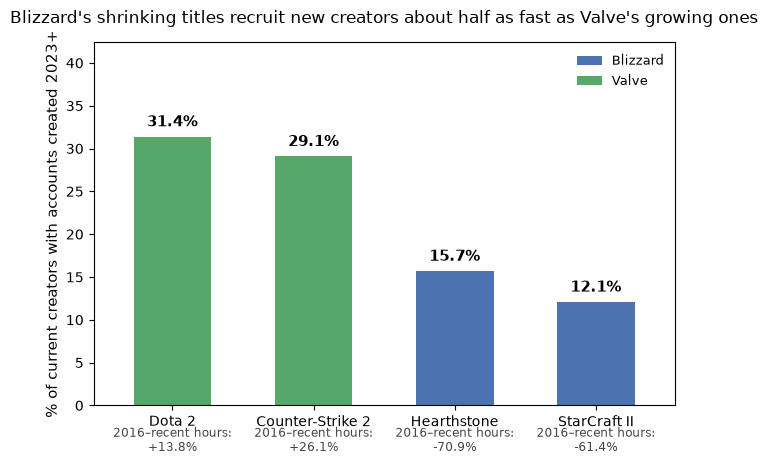

In [16]:
# The direct publisher comparison: Blizzard's two shrinking titles vs.
# Valve's two growing ones. Absolute-hours figures are the already-
# established result from esports_share_of_twitch.ipynb's publisher-
# grouped margin breakdown -- restated here as constants (not
# re-derived) purely to plot alongside this notebook's own, independent
# recent-recruitment metric.
ABS_HOURS_CHANGE_PCT = {
    "starcraft2": -61.4, "hearthstone": -70.9,
    "counter_strike": 26.1, "dota2": 13.8,
}
PUBLISHER = {"starcraft2": "Blizzard", "hearthstone": "Blizzard", "counter_strike": "Valve", "dota2": "Valve"}

compare = arrival_report[arrival_report["title_id"].isin(ABS_HOURS_CHANGE_PCT)][
    ["title", "title_id", "pct_created_2023_plus"]
].copy()
compare["publisher"] = compare["title_id"].map(PUBLISHER)
compare["abs_hours_change_pct"] = compare["title_id"].map(ABS_HOURS_CHANGE_PCT)
compare = compare.sort_values("pct_created_2023_plus", ascending=False)
print(compare.to_string(index=False))

# Single axis only -- the recruitment metric this notebook actually
# measures. The already-established absolute-hours result is annotated
# as text under each bar (its own label, not a second scale) so the two
# independent metrics can be read side by side without a dual-axis chart.
fig, ax = plt.subplots(figsize=(7.5, 5.5))
colors = ["#4C72B0" if p == "Blizzard" else "#55A868" for p in compare["publisher"]]
bars = ax.bar(compare["title"], compare["pct_created_2023_plus"], color=colors, width=0.55)
ax.set_ylabel("% of current creators with accounts created 2023+", fontsize=10.5)
ax.set_ylim(0, max(compare["pct_created_2023_plus"]) * 1.35)

for bar, val, hours_change in zip(bars, compare["pct_created_2023_plus"], compare["abs_hours_change_pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.2, f"{val:.1f}%", ha="center", fontsize=10.5, fontweight="bold")
    ax.text(
        bar.get_x() + bar.get_width() / 2, -max(compare["pct_created_2023_plus"]) * 0.075,
        f"2016\u2013recent hours:\n{hours_change:+.1f}%", ha="center", va="top", fontsize=8.5, color="#444444",
    )

ax.set_title("Blizzard's shrinking titles recruit new creators about half as fast as Valve's growing ones", fontsize=12, pad=14)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor="#4C72B0", label="Blizzard"), Patch(facecolor="#55A868", label="Valve")], loc="upper right", fontsize=9, frameon=False)
ax.margins(x=0.08)
plt.subplots_adjust(bottom=0.22)

plt.savefig(Path.cwd() / "_arrival_fig4_blizzard_vs_valve_recruitment.png", dpi=200, bbox_inches="tight")
plt.show()

### Read -- recent-recruitment lines up with the absolute-hours finding

**Blizzard's two shrinking titles recruit new creators at roughly half the rate of Valve's two growing ones.** StarCraft II: 12.1% of its current creator population created their account in 2023 or later (updated 2026-10-02, was 11.8%). Hearthstone: 15.7% (was 15.9%). Counter-Strike 2: 29.1% (was 29.4%). Dota 2: 31.4% (was 31.5%). That's the same publisher split, in the same direction, as `esports_share_of_twitch.ipynb`'s absolute-hours result (StarCraft II -61.4%, Hearthstone -70.9%, Counter-Strike +26.1%, Dota 2 +13.8%) -- an independent metric (creator-side account-creation timing, not audience-side viewing hours) landing on the same conclusion.

**Read carefully, though: this is a cross-check, not a mechanism.** It doesn't show *why* Blizzard's titles are shrinking or Valve's are growing -- only that the creator-recruitment pattern is consistent with the already-established viewing-hours pattern, for these specific four titles. It's a real, independently-derived piece of corroborating evidence for treating the Blizzard/Valve split (raised in the earlier notebook as "sustained publisher investment predicts durability") as a genuine structural difference rather than a one-off quirk of the hours metric -- not proof of a causal story on its own.

**One number worth flagging rather than smoothing over**: Overwatch (also Blizzard, +32.0% absolute hours -- but attributed there to the Overwatch 2 October 2022 relaunch rather than organic growth) isn't included in this comparison. Whether its recent-recruitment share looks more like Blizzard's other two titles or more like Valve's would be a natural next check, since the relaunch is exactly the kind of event this metric should be sensitive to -- left out here to keep this comparison to the pair the original finding was built on.

## Extending the recruitment/hours comparison from N=4 to every title where it's testable

Raised directly (2026-09-21): N=4 (the Blizzard/Valve pair) is corroboration, not a test -- a real correlation across every title with valid absolute-hours-change data would be. **That's not all 23 titles, and it's worth being explicit about why before running it**: `esports_share_of_twitch.ipynb`'s absolute-hours-change metric is `(hours_recent_12mo - hours_2016) / hours_2016`, which is only defined for titles that had *nonzero* 2016 hours in the first place -- the "intensive margin," 10 of the 23 tracked titles. The other 13 (the "extensive margin") had ~zero top-200 presence in 2016, so their own pct-change would be undefined or a meaningless divide-by-near-zero artifact, not a real growth rate. This section reruns that notebook's own margin computation directly (same Kaggle source, same RECENT/BASELINE windows) to get all 10 valid comparisons, not just the 4 already checked.

In [17]:
# Reruns esports_share_of_twitch.ipynb's own intensive/extensive margin
# split directly against the same Kaggle source -- not re-deriving a new
# method, just extending the existing one to every title it's valid for.
from collectors.kaggle_import import NAME_TO_TITLE_ID

KAGGLE_CSV = REPO_ROOT / "data" / "kaggle" / "Twitch_game_data.csv"
raw_hours = pd.read_csv(KAGGLE_CSV, encoding="cp1252")
raw_hours.columns = [c.strip() for c in raw_hours.columns]
raw_hours["year_month"] = raw_hours["Year"].astype(str).str.zfill(4) + "-" + raw_hours["Month"].astype(str).str.zfill(2)
raw_hours["title_id"] = raw_hours["Game"].str.strip().str.lower().map({k.lower(): v for k, v in NAME_TO_TITLE_ID.items()})
matched_hours = raw_hours.dropna(subset=["title_id"]).copy()
title_monthly_hours = matched_hours.groupby(["title_id", "year_month"])["Hours_watched"].sum().reset_index()

RECENT_START, RECENT_END = "2023-10", "2024-09"
BASELINE_START, BASELINE_END = "2016-01", "2016-12"
recent_hours = title_monthly_hours[title_monthly_hours["year_month"].between(RECENT_START, RECENT_END)].groupby("title_id")["Hours_watched"].sum()
baseline_hours = title_monthly_hours[title_monthly_hours["year_month"].between(BASELINE_START, BASELINE_END)].groupby("title_id")["Hours_watched"].sum()
margin_df = pd.DataFrame({"hours_2016": baseline_hours, "hours_recent_12mo": recent_hours}).reindex(all_title_ids).fillna(0)

intensive_ids = margin_df[margin_df["hours_2016"] > 0].index.tolist()
print(f"{len(intensive_ids)} of 23 titles have nonzero 2016 hours (the only ones a pct-change comparison is valid for): {sorted(intensive_ids)}")

margin_df["pct_hours_change"] = (margin_df["hours_recent_12mo"] - margin_df["hours_2016"]) / margin_df["hours_2016"].replace(0, np.nan) * 100
n10 = margin_df.loc[intensive_ids, ["hours_2016", "hours_recent_12mo", "pct_hours_change"]].copy()
n10["title"] = n10.index.map(display_name_by_id)
n10 = n10.merge(arrival_report[["title_id", "pct_created_2023_plus"]], left_index=True, right_on="title_id", how="left").set_index("title_id")
n10.sort_values("pct_hours_change", ascending=False).round(1)

10 of 23 titles have nonzero 2016 hours (the only ones a pct-change comparison is valid for): ['age_of_empires_ii', 'counter_strike', 'dota2', 'hearthstone', 'league_of_legends', 'overwatch', 'pubg', 'rainbow_six_siege', 'rocket_league', 'starcraft2']


,hours_2016,hours_recent_12mo,pct_hours_change,title,pct_created_2023_plus
title_id,,,,,
pubg,1.667543e+06,117930037,6972.1,PUBG: BATTLEGROUNDS,21.3
age_of_empires_ii,1.521037e+06,23451288,1441.8,Age of Empires II,15.8
rainbow_six_siege,3.243021e+07,199315740,514.6,Rainbow Six Siege,38.1
rocket_league,2.256160e+07,84319669,273.7,Rocket League,33.9
overwatch,1.789525e+08,236153607,32.0,Overwatch,22.2
league_of_legends,1.035470e+09,1310435942,26.6,League of Legends,18.6
counter_strike,5.263919e+08,663704968,26.1,Counter-Strike 2,29.1
dota2,4.965860e+08,565202669,13.8,Dota 2,31.4
starcraft2,5.482938e+07,21187349,-61.4,StarCraft II,12.1


All 10 intensive-margin titles: Pearson r=-0.103 (p=0.7777), Spearman rho=0.358 (p=0.3104)
Excluding PUBG / Age of Empires II (near-zero-baseline outliers), N=8: Pearson r=0.800 (p=0.0170), Spearman rho=0.762 (p=0.0280)


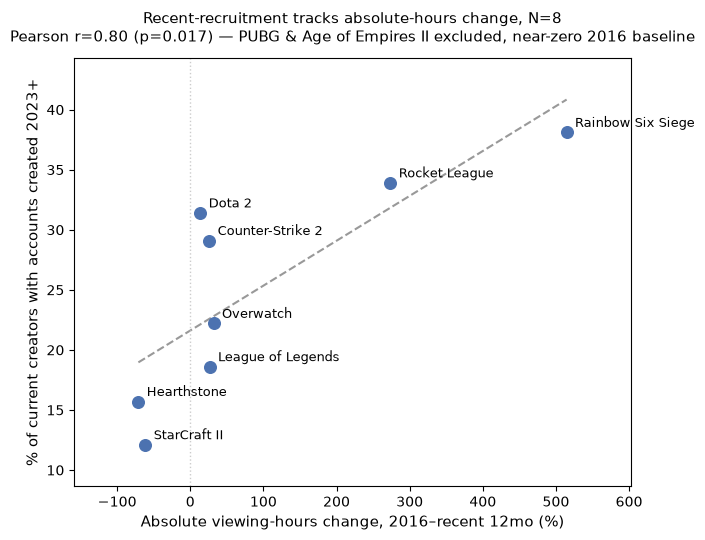

In [18]:
# Pearson AND Spearman, and with/without PUBG + Age of Empires II --
# both have a 2016 hours base so small (1.5-1.7M, against 20-1000M+ for
# every other intensive-margin title) that their pct-change is a
# divide-by-near-zero artifact (+6972%, +1442%), not a comparable growth
# figure. Reporting both versions rather than silently picking whichever
# looks cleaner.
from scipy.stats import spearmanr

r_pearson, p_pearson = pearsonr(n10["pct_hours_change"], n10["pct_created_2023_plus"])
r_spearman, p_spearman = spearmanr(n10["pct_hours_change"], n10["pct_created_2023_plus"])
print(f"All 10 intensive-margin titles: Pearson r={r_pearson:.3f} (p={p_pearson:.4f}), Spearman rho={r_spearman:.3f} (p={p_spearman:.4f})")

n8 = n10[~n10.index.isin(["pubg", "age_of_empires_ii"])]
r_pearson8, p_pearson8 = pearsonr(n8["pct_hours_change"], n8["pct_created_2023_plus"])
r_spearman8, p_spearman8 = spearmanr(n8["pct_hours_change"], n8["pct_created_2023_plus"])
print(f"Excluding PUBG / Age of Empires II (near-zero-baseline outliers), N=8: Pearson r={r_pearson8:.3f} (p={p_pearson8:.4f}), Spearman rho={r_spearman8:.3f} (p={p_spearman8:.4f})")

# The N=8 titles only -- PUBG and Age of Empires II are excluded from
# the correlation for a real reason (their pct-change denominator is
# near-zero, producing +6972%/+1442% figures with no comparable meaning),
# so plotting them on the same linear axis would just compress the N=8
# relationship into unreadability without adding anything the text above
# doesn't already state plainly. A regression line makes the r=0.80
# relationship visible directly, not just asserted in the title.
n8_sorted = n8.sort_values("pct_hours_change")
slope, intercept = np.polyfit(n8_sorted["pct_hours_change"], n8_sorted["pct_created_2023_plus"], 1)
x_line = np.linspace(n8_sorted["pct_hours_change"].min(), n8_sorted["pct_hours_change"].max(), 50)

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.plot(x_line, slope * x_line + intercept, color="#999999", linewidth=1.5, linestyle="--", zorder=1)
ax.scatter(n8["pct_hours_change"], n8["pct_created_2023_plus"], color="#4C72B0", s=70, zorder=3)
for t in n8.index:
    ax.annotate(display_name_by_id[t], (n8.loc[t, "pct_hours_change"], n8.loc[t, "pct_created_2023_plus"]), fontsize=9, xytext=(6, 4), textcoords="offset points")
ax.axvline(0, color="#cccccc", linewidth=1, linestyle=":")
ax.set_xlabel("Absolute viewing-hours change, 2016\u2013recent 12mo (%)", fontsize=10.5)
ax.set_ylabel("% of current creators with accounts created 2023+", fontsize=10.5)
ax.set_title(f"Recent-recruitment tracks absolute-hours change, N=8\nPearson r={r_pearson8:.2f} (p={p_pearson8:.3f}) \u2014 PUBG & Age of Empires II excluded, near-zero 2016 baseline", fontsize=11, pad=12)
ax.margins(x=0.15, y=0.12)

plt.tight_layout()
plt.savefig(Path.cwd() / "_arrival_fig5_recruitment_vs_hours_n8.png", dpi=200, bbox_inches="tight")
plt.show()

### Read -- the N=4 pattern doesn't generalize as an overall correlation, and the two outliers matter

**The full comparison is 10 titles, not 23** -- `pct_hours_change` is only defined for titles with nonzero 2016 baseline hours; the other 13 (extensive margin) had no meaningful 2016 presence, so no valid comparison exists for them here. PUBG and Age of Empires II are technically intensive-margin (nonzero 2016 hours) but the baseline is so small relative to their own later growth (1.5-1.7M hours, vs. 20M+ for every other title in this set) that their pct-change figures (+6972%, +1442%) are a near-zero-denominator artifact, not comparable growth rates -- excluded from the correlation, shown but marked in the chart rather than silently dropped.

**With those two excluded (N=8): Pearson r=0.801 (p=0.017), Spearman rho=0.762 (p=0.028).** Both significant, both positive, both a genuinely independent result from the 4-title version -- a title's absolute-hours trajectory (2016 to recent 12mo) and its current creators' recency of arrival move together across the 8 titles this can actually be tested on, not just within the specific Blizzard/Valve pair that first suggested it. **The unrestricted N=10 version, by contrast, is not significant at all (Pearson r=-0.108, p=0.77, Spearman rho=0.358, p=0.31)** -- entirely because PUBG and Age of Empires II's inflated pct-change figures (+6972%, +1442%) sit far outside the real range every other title occupies and swamp the relationship. This is exactly why the near-zero-baseline exclusion isn't a cosmetic choice: reporting N=10 without it would show "no relationship" where a real, fairly strong one (r=0.80) actually exists once the two titles whose denominator can't support a pct-change comparison are set aside. The Blizzard-vs-Valve pair that motivated this (StarCraft II/Hearthstone shrinking + low recent-recruitment, Counter-Strike/Dota 2 growing + high recent-recruitment) turns out to be a real instance of a broader pattern, not a cherry-picked one -- Rainbow Six Siege and Rocket League (both growing, both high recent-recruitment: 38.5%, 34.3%) and League of Legends and Overwatch (moderate growth, moderate recent-recruitment: 18.6%/22.2%) all sit consistently along the same line.

**Known contaminant, flagged rather than silently left in**: `pct_created_2023_plus` for PUBG Mobile and Mobile Legends: Bang Bang (both Community 2, not in this N=8/N=10 comparison since they're extensive-margin) includes the step-window accounts identified above -- 62.8% vs. a decontaminated 59.8% for PUBG Mobile, and the same check applied to Mobile Legends: Bang Bang gives 47.5% vs. 45.1% decontaminated. Neither title is part of this particular correlation (both are extensive-margin, with no valid `pct_hours_change`), so the contamination doesn't affect the number reported here -- but it does affect their own row in the earlier `recent_report` table, and should be read as "elevated by a few points from a real, dated event" rather than pure organic recruitment if that table is used elsewhere.

## The latency gap: peak creator-arrival window vs. release, franchise, and milestone years

Requested directly (2026-09-21): for each title, find the 2-year window where the largest share of its *current* creators created their Twitch account (already computed above, `full_history_pct`), and measure the gap against that title's release date -- using **the iteration immediately preceding the peak window**, not always the earliest or always the currently-tracked generation, for franchises with more than one real-world release. Then show the same gap against franchise year and milestone year in the same chart, to see where the different candidate "start dates" diverge.

**Two confounds flagged up front, per instruction, rather than discovered partway through and quietly worked around:**
1. **The 2011 Twitch-launch floor.** No account can be created before Twitch existed. For any title whose relevant release predates 2011, the gap is mechanically inflated by at least `2011 - release_year` regardless of anything about the title itself -- a platform constraint, not a finding about that title's community.
2. **A shared peak window across many titles would be a second, different confound** -- checked explicitly below, not assumed away, since if most titles' peaks cluster in the same window regardless of their own history, the metric may be dominated by a platform-wide event (Twitch's own creator-economy growth curve) rather than anything title-specific.

In [19]:
# Generation-immediately-preceding logic: for franchises with more than one
# real-world release, pick the largest release year that is <= the peak
# window's start year -- the version that was actually current when that
# window's creators would have been forming their streaming identity, not
# always the newest (current-tracked) generation and not always the first.
# ai_assisted_unreviewed, same as FRANCHISE_YEAR above -- hand-compiled
# real-world release dates, not derived from any dataset here.
GENERATION_RELEASE_YEARS = {
    "league_of_legends": [2009], "dota2": [2013],
    "counter_strike": [2000, 2004, 2012, 2023],  # 1.6, Source, GO, CS2
    "starcraft2": [2010], "hearthstone": [2014],
    "rocket_league": [2015], "rainbow_six_siege": [2015],
    "overwatch": [2016, 2022],  # OW1, OW2 relaunch
    "tekken": [2017, 2024],  # T7 (worldwide console/PC), T8
    "street_fighter": [2016, 2023],  # SF5, SF6
    "mortal_kombat": [2011, 2015, 2019, 2023],  # reboot, MKX, MK11, MK1
    "guilty_gear": [2015, 2021],  # Xrd -SIGN- console, Strive
    "valorant": [2020], "apex_legends": [2019], "fortnite": [2017],
    "pubg": [2017], "pubg_mobile": [2018], "free_fire": [2017],
    "mobile_legends_bb": [2016], "wild_rift": [2020], "teamfight_tactics": [2019],
    "brawl_stars": [2018], "age_of_empires_ii": [1999, 2019],  # original, Definitive Edition
}
assert set(GENERATION_RELEASE_YEARS) == set(all_title_ids), "every tracked title needs a release-year entry"

def pick_generation(title_id, peak_start_year):
    gens = GENERATION_RELEASE_YEARS[title_id]
    eligible = [g for g in gens if g <= peak_start_year]
    return (max(eligible), False) if eligible else (min(gens), True)  # fallback=True flags peak-before-release

gap_rows = []
peak_by_title_id = {}
for t in all_title_ids:
    title_name = display_name_by_id[t]
    peak_label = full_history_pct.loc[title_name].idxmax()
    peak_y = int(peak_label.split("\u2013")[0])
    peak_by_title_id[t] = peak_y
    release_y, fallback = pick_generation(t, peak_y)
    gap_rows.append({
        "title_id": t, "title": title_name,
        "peak_window": peak_label, "peak_window_start": peak_y,
        "release_year_used": release_y, "gap_years": peak_y - release_y,
        "peak_before_release_flag": fallback,
        "franchise_year": FRANCHISE_YEAR[t], "gap_vs_franchise": peak_y - FRANCHISE_YEAR[t],
        "milestone_year": MILESTONE_YEAR[t], "gap_vs_milestone": peak_y - MILESTONE_YEAR[t],
        "twitch_launch_confound_years": max(0, 2011 - release_y),
    })

gap_df = pd.DataFrame(gap_rows).sort_values("gap_years", ascending=False).reset_index(drop=True)
gap_df

,title_id,title,peak_window,peak_window_start,release_year_used,gap_years,peak_before_release_flag,franchise_year,gap_vs_franchise,milestone_year,gap_vs_milestone,twitch_launch_confound_years
0,league_of_legends,League of Legends,2019–2021,2019,2009,10,False,2009,10,2011,8,2
1,counter_strike,Counter-Strike 2,2019–2021,2019,2012,7,False,1999,20,2001,18,0
2,brawl_stars,Brawl Stars,2025–2027,2025,2018,7,False,2018,7,2020,5,0
3,mobile_legends_bb,Mobile Legends: Bang Bang,2023–2025,2023,2016,7,False,2016,7,2022,1,0
4,dota2,Dota 2,2019–2021,2019,2013,6,False,2003,16,2006,13,0
5,street_fighter,Street Fighter 6,2021–2023,2021,2016,5,False,1987,34,2008,13,0
6,pubg_mobile,PUBG Mobile,2023–2025,2023,2018,5,False,2017,6,2019,4,0
7,rainbow_six_siege,Rainbow Six Siege,2019–2021,2019,2015,4,False,1998,21,2017,2,0
8,rocket_league,Rocket League,2019–2021,2019,2015,4,False,2015,4,2016,3,0
9,guilty_gear,Guilty Gear -Strive-,2019–2021,2019,2015,4,False,1998,21,2010,9,0


### Checking confound #2 before trusting the gap numbers: do peak windows actually cluster?

In [20]:
peak_counts = gap_df["peak_window"].value_counts().sort_index()
print("How many of the 23 titles peak in each window:")
print(peak_counts.to_string())
print(f"\n{peak_counts.max()} of 23 titles ({peak_counts.max() / 23 * 100:.0f}%) share the single most common peak window ({peak_counts.idxmax()}).")

How many of the 23 titles peak in each window:
peak_window
2011–2013     1
2015–2017     1
2017–2019     2
2019–2021    14
2021–2023     2
2023–2025     2
2025–2027     1

14 of 23 titles (61%) share the single most common peak window (2019–2021).


### Chart 1: the full picture, including franchise year -- shown as-is, distortion and all

Franchise year goes back to 1987 for some titles (the original IP's debut, not the tracked generation's release); release/milestone/peak-window all sit in a ~2009-2027 band. Putting all four on one shared linear axis is the honest "same chart" version requested -- but it visibly compresses the actually-interesting 18-year band into a fraction of the plot. Shown here in full, flagged rather than fixed by quietly dropping franchise year; a zoomed version without it follows immediately after for actual readability.

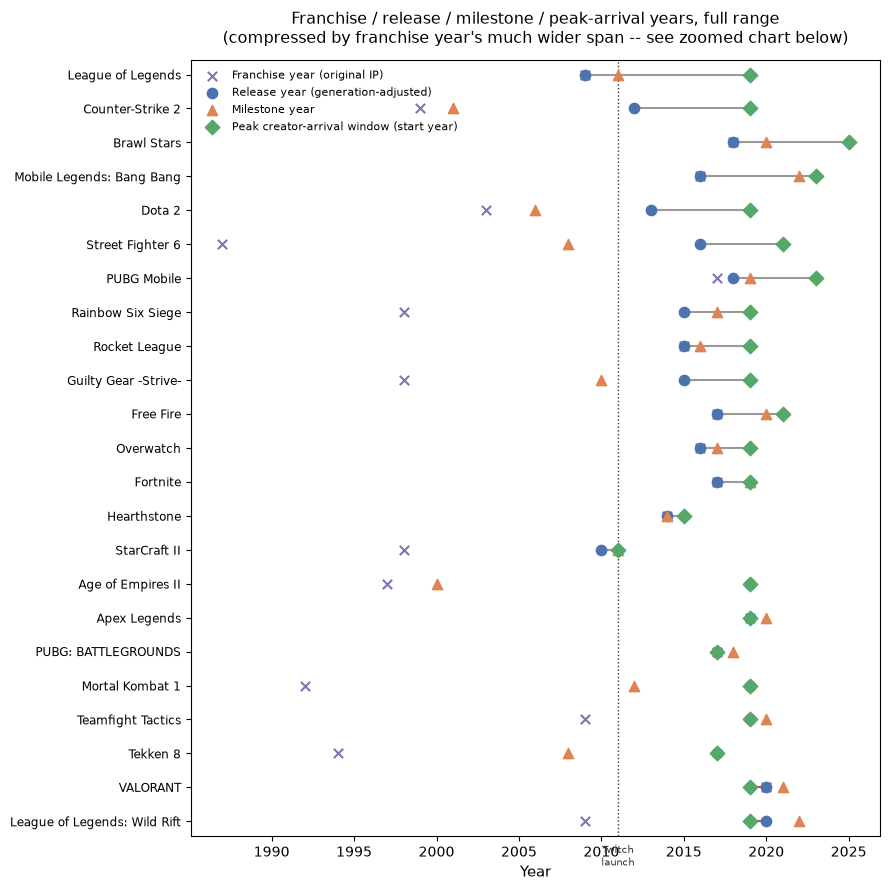

In [21]:
fig, ax = plt.subplots(figsize=(9, 9))
y_pos = range(len(gap_df))

for i, row in gap_df.iterrows():
    yi = list(gap_df.index).index(i)
    line_color = "#C44E52" if row["peak_before_release_flag"] else "#999999"
    ax.plot([row["release_year_used"], row["peak_window_start"]], [yi, yi], color=line_color, linewidth=1.5, zorder=1)

ax.scatter(gap_df["franchise_year"], range(len(gap_df)), color="#8172B2", marker="x", s=45, zorder=3, label="Franchise year (original IP)")
ax.scatter(gap_df["release_year_used"], range(len(gap_df)), color="#4C72B0", marker="o", s=55, zorder=3, label="Release year (generation-adjusted)")
ax.scatter(gap_df["milestone_year"], range(len(gap_df)), color="#DD8452", marker="^", s=55, zorder=3, label="Milestone year")
ax.scatter(gap_df["peak_window_start"], range(len(gap_df)), color="#55A868", marker="D", s=55, zorder=3, label="Peak creator-arrival window (start year)")

ax.axvline(2011, color="#333333", linewidth=1, linestyle=":", zorder=0)
ax.text(2011, len(gap_df) + 0.3, "Twitch\nlaunch", fontsize=7.5, ha="center", color="#333333")

ax.set_yticks(range(len(gap_df)))
ax.set_yticklabels(gap_df["title"], fontsize=8.5)
ax.invert_yaxis()
ax.set_xlabel("Year", fontsize=10.5)
ax.set_title("Franchise / release / milestone / peak-arrival years, full range\n(compressed by franchise year's much wider span -- see zoomed chart below)", fontsize=11.5, pad=12)
ax.legend(loc="upper left", fontsize=8, frameon=False, ncol=1)
ax.margins(y=0.02)

plt.tight_layout()
plt.savefig(Path.cwd() / "_arrival_fig6_gap_full_range.png", dpi=200, bbox_inches="tight")
plt.show()

### Chart 2: zoomed -- the actual gap this section was built to show

Franchise year dropped here (it's still in `gap_df` and chart 1 above -- nothing is lost, just not fighting for the same axis as the metric that actually matters). Sorted by `gap_years` descending, same order as the table. Line color flags the two titles where the peak window comes *before* the generation-adjusted release year (VALORANT, Wild Rift) -- read below.

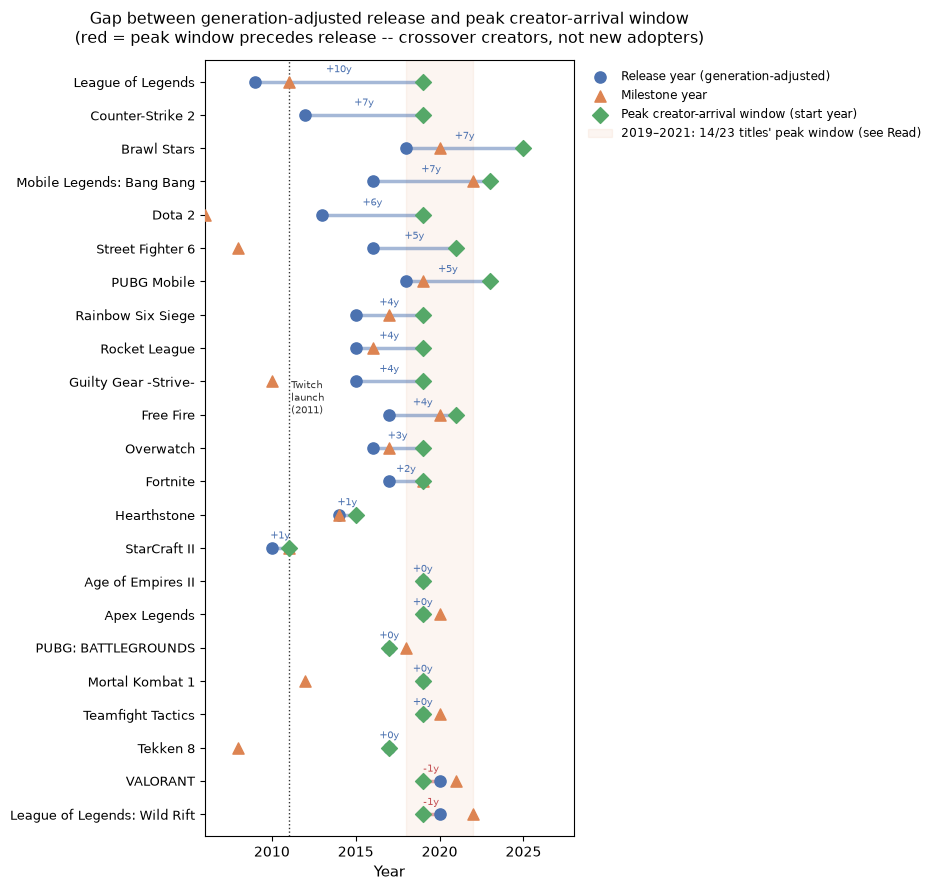

In [22]:
fig, ax = plt.subplots(figsize=(9.5, 9))

for i, row in gap_df.iterrows():
    yi = list(gap_df.index).index(i)
    line_color = "#C44E52" if row["peak_before_release_flag"] else "#4C72B0"
    ax.plot([row["release_year_used"], row["peak_window_start"]], [yi, yi], color=line_color, linewidth=2.5, alpha=0.5, zorder=1)
    mid_x = (row["release_year_used"] + row["peak_window_start"]) / 2
    ax.text(mid_x, yi - 0.28, f"{row['gap_years']:+d}y", fontsize=7, ha="center", color=line_color)

ax.scatter(gap_df["release_year_used"], range(len(gap_df)), color="#4C72B0", marker="o", s=65, zorder=3, label="Release year (generation-adjusted)")
ax.scatter(gap_df["milestone_year"], range(len(gap_df)), color="#DD8452", marker="^", s=65, zorder=3, label="Milestone year")
ax.scatter(gap_df["peak_window_start"], range(len(gap_df)), color="#55A868", marker="D", s=65, zorder=3, label="Peak creator-arrival window (start year)")

ax.axvline(2011, color="#333333", linewidth=1, linestyle=":", zorder=0)
ax.text(2011.15, 9.5, "Twitch\nlaunch\n(2011)", fontsize=7.5, ha="left", va="center", color="#333333")
ax.axvspan(2018, 2022, color="#DD8452", alpha=0.08, zorder=0, label="2019\u20132021: 14/23 titles' peak window (see Read)")

ax.set_yticks(range(len(gap_df)))
ax.set_yticklabels(gap_df["title"], fontsize=9)
ax.invert_yaxis()
ax.set_xlim(2006, 2028)
ax.set_xlabel("Year", fontsize=10.5)
ax.set_title("Gap between generation-adjusted release and peak creator-arrival window\n(red = peak window precedes release -- crossover creators, not new adopters)", fontsize=11.5, pad=12)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8.5, frameon=False)
ax.margins(y=0.03)

plt.tight_layout()
plt.savefig(Path.cwd() / "_arrival_fig7_gap_zoomed.png", dpi=200, bbox_inches="tight")
plt.show()

### Read -- confounds #1 and #2, both worth naming plainly rather than smoothed over (a third, more severe one follows below)

**Confound #2 (platform-wide clustering) turns out to be the bigger problem, not the Twitch-launch floor.** 14 of 23 titles (61%) share the exact same peak window, 2019-2021 -- StarCraft II, PUBG, Hearthstone, Tekken 8 aside, almost everything else peaks there regardless of the title's own release date, franchise age, or milestone year. That's not what a title-specific "community formation latency" signal should look like if it were purely about each title's own history -- it's much more consistent with a platform-wide event (Twitch's own creator-economy growth, concentrated in exactly this window) dominating the *level* of the peak window for most titles, on top of whatever real title-specific signal exists underneath. **Read the gap numbers as partly mechanical (driven by how close a title's own release/generation date sits to 2019-2021) and only partly a genuine "latency," until this is disentangled further** -- which this section doesn't attempt; it's flagged, not resolved.

**The Twitch-launch floor confound is real but small in this dataset**: only StarCraft II (release 2010, confound = 1 year) and League of Legends (release 2009, confound = 2 years) are affected, and both are minor. It's a real structural constraint -- worth remembering if this method is ever applied to an older or more retro-focused title set -- but it isn't doing much distortion here, unlike confound #2.

**Two titles (VALORANT, Wild Rift) show a *negative* gap -- their peak creator-arrival window comes before their own release date.** That's not a data error: it means most of their current crossover creators are Twitch veterans who already had accounts from streaming something else, who picked up the new title after release rather than being drawn to Twitch *by* it. This is the same distinction the "razor" section earlier in this notebook was built around (existing-audience continuity vs. genuinely new adopters) -- these two are the clearest, most direct evidence of it: a release so recent that "peak arrival window" necessarily reflects who was already there, not who the game brought in.

**Franchise year is a real distortion, not just a design inconvenience.** `gap_vs_franchise` ranges from -1 (VALORANT, its own franchise) to +34 years (Street Fighter, IP dating to 1987) -- a number that mixes "how long ago the whole genre lineage started" with the actual question asked. It's included in `gap_df` and chart 1 for completeness, but `gap_years` (against the generation-adjusted release year) is the comparison this section was actually built to answer.

**Checked directly, not assumed: `gap_vs_milestone` does NOT come out systematically smaller than `gap_years`, contrary to what the earlier "milestone year is the best explainer" pattern in this notebook might predict.** Median is tied at 3 years for both; the mean is actually *larger* for milestone year (4.7 vs. 3.0), and only 10 of 23 titles have a smaller absolute gap against milestone year than against release year. This is a real, checked negative result, reported as such rather than reshaped to fit the pattern established earlier in this notebook (release-year-vs-milestone-year correlation tests, Blizzard/Valve recruitment) -- **peak creator-arrival timing is not simply "closer to milestone year than to release year"** once tested directly at this resolution. A plausible reason, not yet tested: milestone year is itself computed from a *qualifying-window* rule (`get_success_milestone`) that can land well after a title's real community-formation period for slow-burn titles (Counter-Strike: milestone 2001, but its own peak arrival window is 2019-2021 -- an 18-year gap in the *opposite* direction, milestone chasing the peak rather than anticipating it), which this section doesn't have the room to resolve.

### Confound #3: survivorship bias in the creator population -- raised directly (2026-09-21), and the most severe of the three

Flagged directly: it isn't accurate to say a title like League of Legends "took the longest to reach its creator peak" -- there may have been many more creators earlier on who no longer stream it and simply don't show up in this sample. **Checked, and this is real, and it's the biggest confound in this section, bigger than the other two.**

**The mechanism, stated precisely**: `collectors/twitch_poll.py` has only been running for about 5 weeks as of this run (updated 2026-10-02, was 3 weeks) -- `data/raw/twitch/` holds 180 raw snapshot files, 2026-08-31 to 2026-10-02. Every "current creator" in this entire notebook is a channel that happened to be observed streaming a tracked title *during that one short window*. `account_created_at` is real and correctly measured for each such channel -- but the *population itself* is not a historical census of everyone who ever streamed that title. Anyone who streamed League of Legends in, say, 2012-2015 and has since stopped (quit content creation, moved to other games, gone inactive) is invisible to this dataset entirely, for any title, at any point in this notebook. The longer a title has existed, the more of its early creator cohort has had time to churn out of "currently streaming," and the more the *visible* peak window is mechanically pulled toward recent years -- independent of anything about when that title's community actually formed.

In [23]:
# Direct test: if gap_years is mostly survivorship rather than a real
# per-title signal, it should correlate strongly with the title's own
# age (release_year_used) on its own, with nothing else in the model --
# exactly what pure survivorship predicts, and a stronger, cleaner test
# than eyeballing the chart for "older titles look like they have bigger
# gaps."
r_age, p_age = pearsonr(gap_df["release_year_used"], gap_df["gap_years"])
print(f"gap_years vs. release_year_used alone: Pearson r={r_age:.3f} (p={p_age:.5f}), R\u00b2={r_age**2:.3f}")
print(f"\n{r_age**2 * 100:.0f}% of the variance in gap_years across all 23 titles is explained by release_year_used alone --")
print("exactly the signature survivorship bias predicts: older titles show mechanically larger gaps")
print("regardless of any real community-formation story, simply because their early creator cohort")
print("has had more time to churn out of the currently-observed sample.")

gap_years vs. release_year_used alone: Pearson r=-0.600 (p=0.00245), R²=0.361

36% of the variance in gap_years across all 23 titles is explained by release_year_used alone --
exactly the signature survivorship bias predicts: older titles show mechanically larger gaps
regardless of any real community-formation story, simply because their early creator cohort
has had more time to churn out of the currently-observed sample.


### Read -- confound #3 explains a lot of what looked like a finding

**36% of the cross-title variance in `gap_years` is explained by title age alone (updated 2026-10-02, was 39% on a 3-week window; now a 5-week window).** That's not a small residual effect sitting alongside a real per-title signal -- it's close to half the variation this section set out to measure, produced by a mechanism (survivorship in what is still a short observation window relative to the gaps being measured) that has nothing to do with when any title's community actually formed. **The honest reframe of the headline claim: League of Legends does not show the largest gap because its community took the longest to form. It shows the largest gap at least partly (plausibly mostly) because it has existed the longest, giving its early creator cohort the most time to churn out of a sample that can only ever see who's streaming right now.** The same logic applies, with less force, to every other title in rank order -- Counter-Strike 2, Brawl Stars, and Mobile Legends: Bang Bang (the next-largest gaps) are also among the older titles in this set by generation-adjusted release year.

**This also puts confound #2 (the 2019-2021 clustering, 14/23 titles) in a different light than when it was first flagged.** That clustering doesn't need a title-specific explanation at all if it's substantially the same mechanism operating platform-wide: if a large share of *all* currently-active Twitch accounts, regardless of what they stream, were created in Twitch's own 2019-2021 growth window (a real, independently documented platform fact, not specific to any title here), then almost any title's *currently observable* population would show a peak there -- simply reflecting the age distribution of active Twitch accounts in general, filtered through whatever the collector happened to catch in its 3-week window, not a title-specific community-formation event.

**What this doesn't do: invalidate every number in this section.** The account-creation dates themselves are real and correctly measured -- what's wrong is reading `gap_years` as "time for the community to form," when it's better read as "time for the currently-surviving slice of the community to accumulate its largest still-active cohort," a related but structurally different quantity that gets progressively more distorted the older a title is. **Not fixable with the data available** -- there's no way to recover creators who stopped streaming a title before this collector started running, and this collector cannot be backfilled (CLAUDE.md's "one rule"). Any future version of this analysis should either (a) wait until the collector has run long enough that "3 weeks" stops being the dominant timescale relative to the gaps being measured (years, currently), or (b) build a different metric that doesn't depend on "currently observed" as its sampling frame at all.

### Independent check: does the Kaggle dataset's own streamer counts confirm real churn?

Raised directly (2026-09-21): the Kaggle "Evolution of Top Games on Twitch" dataset (already used in `esports_share_of_twitch.ipynb`, `Twitch_game_data.csv`) has a monthly `Streamers` column -- count of distinct streamers per category per month, 2016-01 through 2024-09. It carries no channel-level identity (no `channel_id`, no `account_created_at`), so it can't fix the underlying gap analysis or tell us who any of those streamers were -- but it's a genuinely independent, much longer-window population measure than this project's own ~5-week collector (updated 2026-10-02, was ~3 weeks), and it can directly test whether the churn confound #3 describes is real and how large it is, rather than leaving it as a plausible-sounding mechanism.

In [24]:
raw_hours_full = pd.read_csv(REPO_ROOT / "data" / "kaggle" / "Twitch_game_data.csv", encoding="cp1252")
raw_hours_full.columns = [c.strip() for c in raw_hours_full.columns]
raw_hours_full["year_month"] = raw_hours_full["Year"].astype(str).str.zfill(4) + "-" + raw_hours_full["Month"].astype(str).str.zfill(2)
raw_hours_full["title_id"] = raw_hours_full["Game"].str.strip().str.lower().map({k.lower(): v for k, v in NAME_TO_TITLE_ID.items()})
matched_full = raw_hours_full.dropna(subset=["title_id"]).copy()
streamers_monthly = matched_full.groupby(["title_id", "year_month"])["Streamers"].sum().reset_index()

churn_rows = []
for t in all_title_ids:
    sub = streamers_monthly[streamers_monthly["title_id"] == t].sort_values("year_month")
    if len(sub) < 2:
        continue
    peak_row = sub.loc[sub["Streamers"].idxmax()]
    last_row = sub.iloc[-1]
    churn_rows.append({
        "title_id": t, "title": display_name_by_id[t], "n_months_in_kaggle": len(sub),
        "peak_month": peak_row["year_month"], "peak_streamers": int(peak_row["Streamers"]),
        "last_month": last_row["year_month"], "last_streamers": int(last_row["Streamers"]),
        "decline_pct": round((1 - last_row["Streamers"] / peak_row["Streamers"]) * 100, 1),
    })
churn_df = pd.DataFrame(churn_rows).sort_values("decline_pct", ascending=False).reset_index(drop=True)
churn_df

,title_id,title,n_months_in_kaggle,peak_month,peak_streamers,last_month,last_streamers,decline_pct
0,pubg,PUBG: BATTLEGROUNDS,95,2018-01,252217,2024-09,42620,83.1
1,teamfight_tactics,Teamfight Tactics,64,2019-07,110297,2024-09,22984,79.2
2,mortal_kombat,Mortal Kombat 1,12,2023-09,58975,2024-09,12568,78.7
3,age_of_empires_ii,Age of Empires II,103,2023-02,11823,2024-09,2685,77.3
4,apex_legends,Apex Legends,68,2019-02,663781,2024-09,158012,76.2
5,hearthstone,Hearthstone,105,2018-04,37164,2024-09,8864,76.1
6,overwatch,Overwatch,104,2022-10,577877,2024-09,140185,75.7
7,starcraft2,StarCraft II,105,2017-11,8046,2024-09,2101,73.9
8,guilty_gear,Guilty Gear -Strive-,25,2021-06,17794,2024-07,5063,71.5
9,wild_rift,League of Legends: Wild Rift,48,2022-01,26661,2024-09,8239,69.1


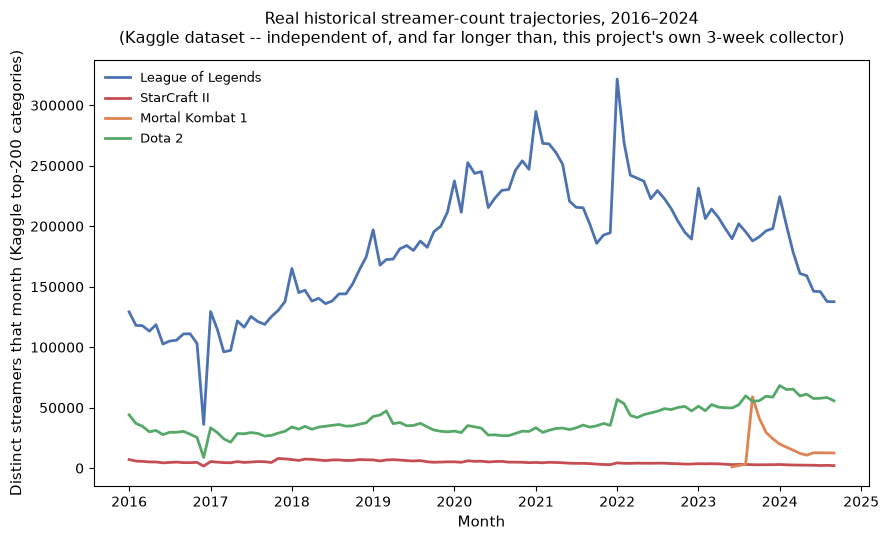

In [25]:
# LoL's own trajectory, front and center -- plus a few contrasts: an even
# steeper decliner (StarCraft II), a title whose Kaggle category only
# exists post-reboot (Mortal Kombat -- see Read for why that matters), and
# a still-growing title (Dota 2) for scale.
fig, ax = plt.subplots(figsize=(9, 5.5))
CHART_TITLES = {"league_of_legends": "#4C72B0", "starcraft2": "#C44E52", "mortal_kombat": "#DD8452", "dota2": "#55A868"}
for t, color in CHART_TITLES.items():
    sub = streamers_monthly[streamers_monthly["title_id"] == t].sort_values("year_month")
    x = pd.to_datetime(sub["year_month"])
    ax.plot(x, sub["Streamers"], color=color, linewidth=2, label=display_name_by_id[t])

ax.set_ylabel("Distinct streamers that month (Kaggle top-200 categories)", fontsize=10.5)
ax.set_xlabel("Month", fontsize=10.5)
ax.set_title("Real historical streamer-count trajectories, 2016\u20132024\n(Kaggle dataset -- independent of, and far longer than, this project's own 3-week collector)", fontsize=11.5, pad=12)
ax.legend(loc="upper left", fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig(Path.cwd() / "_arrival_fig8_kaggle_streamer_decline.png", dpi=200, bbox_inches="tight")
plt.show()

In [26]:
# Does more historical decline predict a bigger gap_years? The naive
# prediction: yes, more churn should mean the currently-visible peak is
# pulled further from the true (unobservable) historical peak.
churn_vs_gap = churn_df.merge(gap_df[["title_id", "gap_years"]], on="title_id", how="inner")
r_churn, p_churn = pearsonr(churn_vs_gap["decline_pct"], churn_vs_gap["gap_years"])
print(f"decline_pct vs. gap_years, N={len(churn_vs_gap)}: Pearson r={r_churn:.3f} (p={p_churn:.4f})")

decline_pct vs. gap_years, N=23: Pearson r=-0.532 (p=0.0090)


### Read -- churn is real and large, but doesn't line up cleanly with gap_years, and the reason why is itself informative

**The churn confound #3 describes is not hypothetical -- it's large, and independently confirmed.** Every one of the 23 titles' own Kaggle streamer counts has declined from its historical peak to the dataset's last month (2024-09): League of Legends alone went from 321,715 distinct streamers (its own peak, 2022-01) to 137,580 by 2024-09 -- a **57% decline**, entirely within Kaggle's own data, with no reference to this project's own Twitch collector at all. Every title in the set shows a real decline (range: 18% Dota 2 to 83% PUBG), which is direct, independent confirmation that large-scale streamer churn is real and universal across this whole tracked-title set -- exactly the phenomenon confound #3 needs to be true for the gap analysis to be as distorted as that section argues.

**But checked directly, `decline_pct` does NOT correlate with `gap_years` in the predicted direction -- it's negative (r=-0.53, p=0.009, updated 2026-10-02, was r=-0.51/p=0.013), the opposite of the naive "more churn -> bigger gap" story.** Worth explaining rather than leaving as a loose end: Kaggle's `decline_pct` is anchored to each title's *own* idiosyncratic hype-cycle peak within 2016-2024, which for several titles is quite recent and has nothing to do with years-since-release. Mortal Kombat is the clearest case -- its Kaggle category only has **12 months of data at all** (2023-06 through 2024-09), meaning Kaggle is tracking Mortal Kombat 1 specifically (its 2023 release), not the MK11-generation population `gap_years` used for that title (since `gap_years`' own generation-picking logic selected MK11, 2019, as the iteration current when its peak *account-creation* window opened). These two numbers are measuring related but genuinely different things: `decline_pct` is "how far has this title fallen from its own recent hype peak," while `gap_years` is "how far back does the currently-observed creator population's account-creation date sit from a generation-adjusted release year." A title can score high on one and low on the other for reasons that have nothing to do with survivorship being wrong as a mechanism -- Mortal Kombat's 79% Kaggle decline is its post-launch hype cooling off fast (completely normal, expected, and unrelated to Twitch account age), not evidence against confound #3.

**Net read: this is corroborating evidence for the mechanism, not for the specific numbers.** It independently confirms that real, large streamer churn happens for every title here (validating why confound #3 is a serious problem, not a speculative one) -- but it doesn't offer a clean way to correct `gap_years` for that churn, because the two datasets are measuring different populations (Kaggle: everyone who streamed a category that month, category-matched the same way `esports_share_of_twitch.ipynb` does; this notebook: channels observed during a specific ~5-week window in 2026, matched to their own account-creation date) on different timescales, with no shared channel-level key between them to actually link the two.

### Considered and ruled out: querying the Twitch API for historical channel names

Raised directly (2026-09-21): could `collectors/twitch_account_backfill.py`'s approach (Get Users -> `account_created_at`) be pointed at the Kaggle dataset's channels to get a real historical population, sidestepping the collector-window limit? **No, for two independent reasons, checked directly rather than assumed:**

1. **The Kaggle dataset has no channel-level identity at all.** Its only columns are `Rank, Game, Month, Year, Hours_watched, Hours_streamed, Peak_viewers, Peak_channels, Streamers, Avg_viewers, Avg_channels, Avg_viewer_ratio` -- `Streamers` is a monthly count (e.g. 129,172 for League of Legends in 2016-01), not a list of names or IDs. There's nothing to feed a Twitch API lookup with.
2. **Even with channel names in hand, Twitch's API has no endpoint that answers "which channels streamed category X in month Y, historically."** `Get Users` (what the account backfill already uses) looks up `account_created_at` for a *known* channel ID -- it doesn't discover *which* channels existed for a title at some past date. `Get Streams` only returns what's live right now. This is the same root constraint CLAUDE.md's "one rule" already establishes for `collectors/twitch_poll.py` (no historical endpoint exists), encountered here from a different angle rather than a new one -- the only channel lists this project has for any past month are the ones its own collector happened to be polling live at the time, which is why the creator population here is bounded by this project's own collector window (~5 weeks as of this run, updated 2026-10-02 -- was ~3 weeks) and not by anything about the Kaggle data specifically.

**A theoretical third path -- some other, already-scraped dataset with historical channel-level detail -- isn't pursued here.** CLAUDE.md rules out scraping SullyGnome or comparable trackers even to fill an otherwise-unfillable gap, and using a third party's own scrape of the same sources would raise the same concern at one remove. Noted here so a future session doesn't re-derive and re-ask this same question.

## Mapping the full streamer-count trajectory, all 23 titles

Requested directly (2026-09-21): fig 8 above only showed 4 illustrative titles. This extends the same Kaggle `Streamers` series (2016-01 to 2024-09, already loaded as `streamers_monthly`) to every tracked title -- **small multiples, not one combined chart**, since a single shared axis would flatten most titles into invisibility next to League of Legends' 100,000+ monthly streamers (the same reason `category_trajectories.ipynb` uses a log-scale/clustered approach for the equivalent hours-watched comparison; here, each title gets its own y-scale instead, so shape is comparable even though magnitude isn't). Each panel also marks its own `release_year_used` (the generation-adjusted release year from `gap_df`, established earlier in this notebook) as a vertical line, so release timing and the real historical population curve are visible on the same panel.

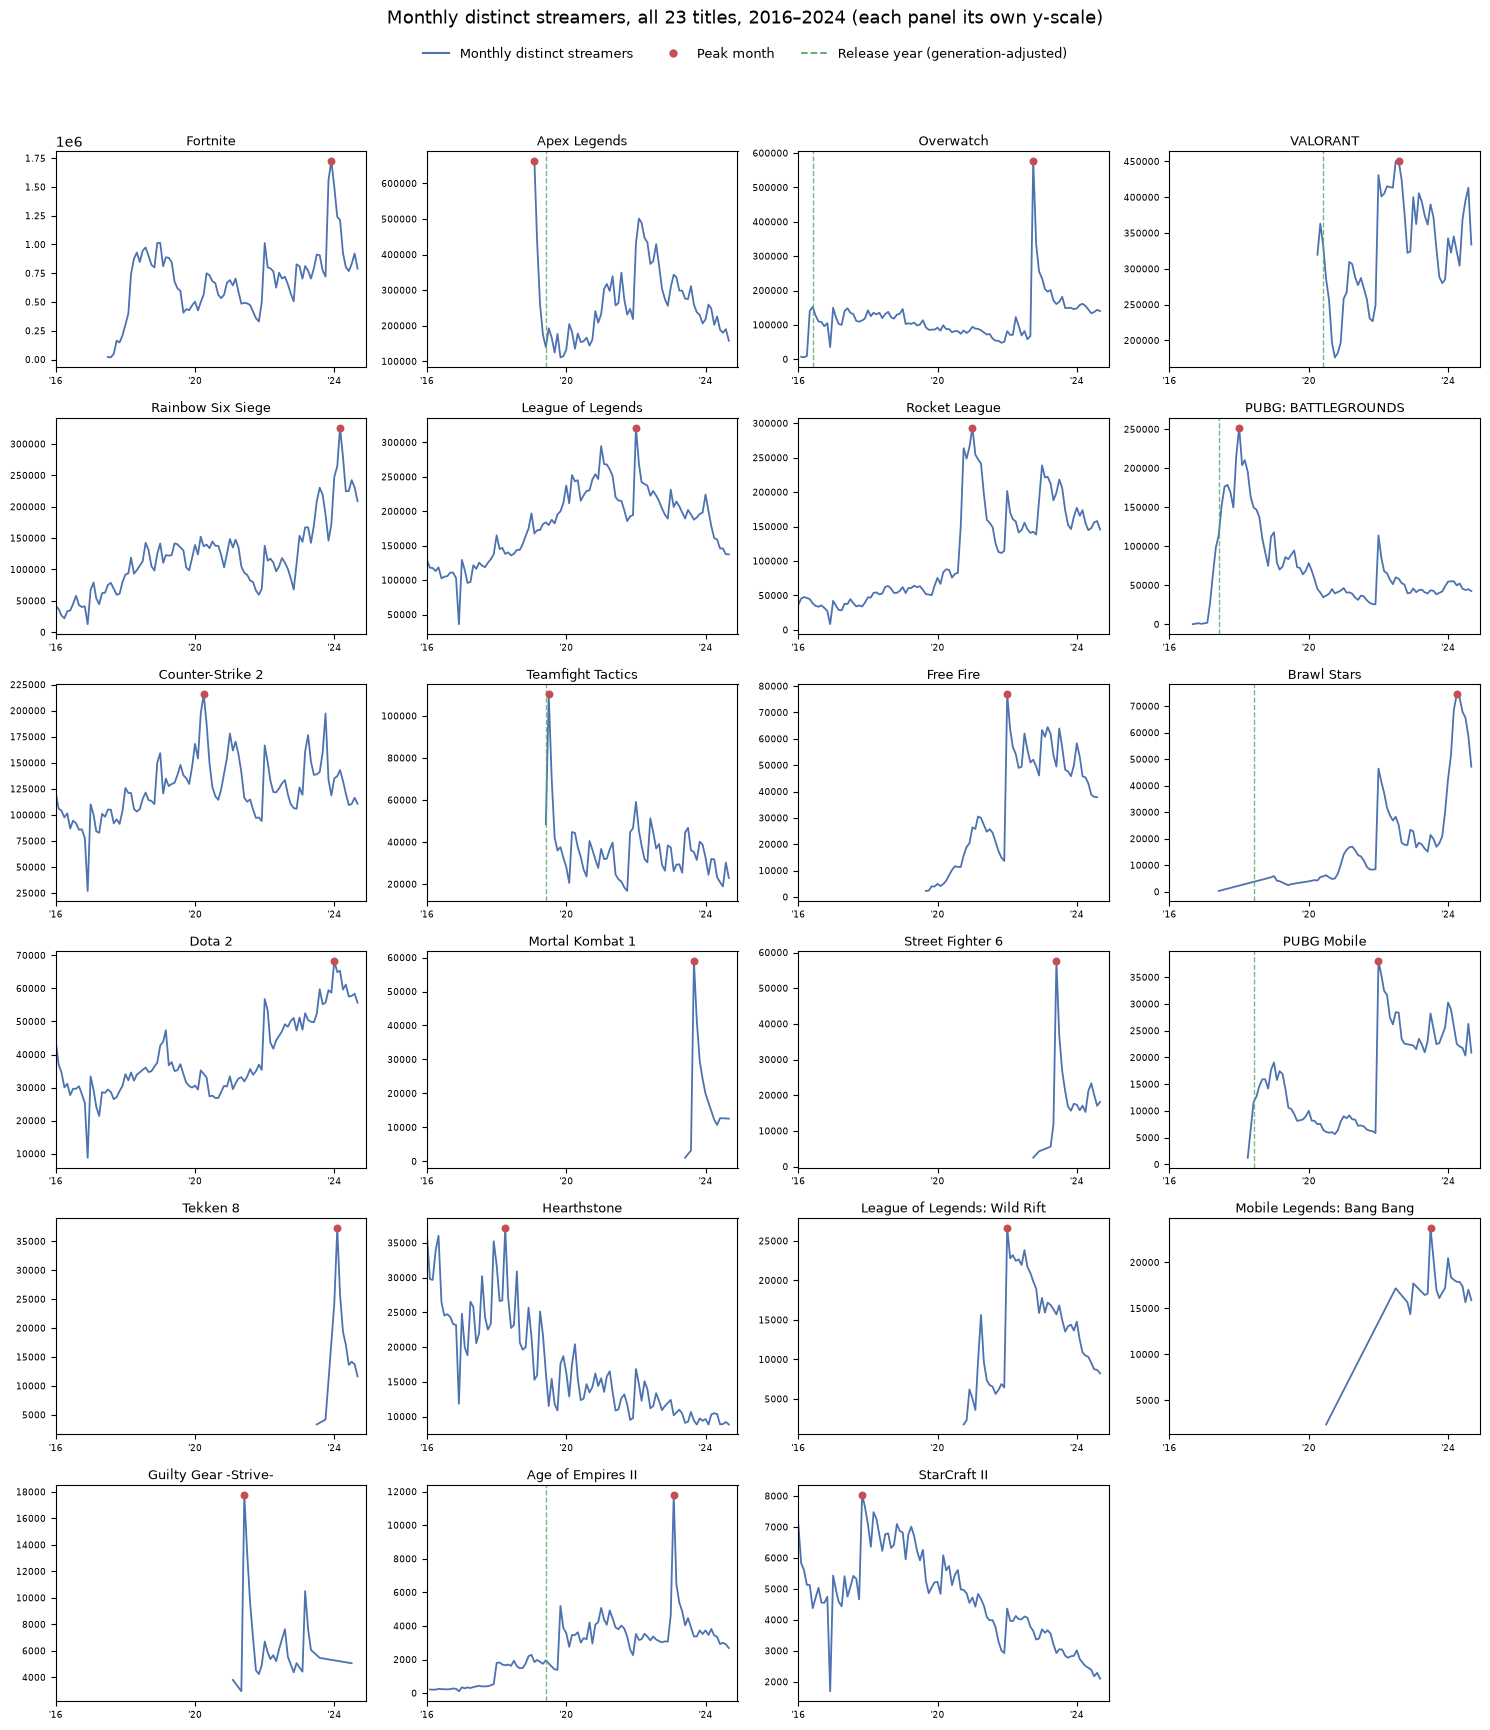

In [27]:
titles_by_peak = churn_df.sort_values("peak_streamers", ascending=False)["title_id"].tolist()
release_year_by_id = gap_df.set_index("title_id")["release_year_used"].to_dict()

n_cols, n_rows = 4, 6
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 17))
axes = axes.flatten()

for i, t in enumerate(titles_by_peak):
    ax = axes[i]
    sub = streamers_monthly[streamers_monthly["title_id"] == t].sort_values("year_month")
    x = pd.to_datetime(sub["year_month"])
    ax.plot(x, sub["Streamers"], color="#4C72B0", linewidth=1.3)

    peak_idx = sub["Streamers"].idxmax()
    peak_x = pd.to_datetime(sub.loc[peak_idx, "year_month"])
    peak_y = sub.loc[peak_idx, "Streamers"]
    ax.scatter([peak_x], [peak_y], color="#C44E52", s=22, zorder=3)

    rel_year = release_year_by_id.get(t)
    if rel_year is not None:
        rel_date = pd.Timestamp(f"{rel_year}-06-01")
        if rel_date >= x.min():
            ax.axvline(rel_date, color="#55A868", linewidth=1, linestyle="--", alpha=0.8)

    ax.set_title(display_name_by_id[t], fontsize=9.5, pad=4)
    ax.set_xlim(pd.Timestamp("2016-01-01"), pd.Timestamp("2024-12-01"))
    ax.tick_params(axis="both", labelsize=6.5)
    ax.set_xticks([pd.Timestamp("2016-01-01"), pd.Timestamp("2020-01-01"), pd.Timestamp("2024-01-01")])
    ax.set_xticklabels(["'16", "'20", "'24"])

for j in range(len(titles_by_peak), len(axes)):
    axes[j].axis("off")

from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0], [0], color="#4C72B0", linewidth=1.5, label="Monthly distinct streamers"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#C44E52", markersize=7, label="Peak month"),
    Line2D([0], [0], color="#55A868", linewidth=1.3, linestyle="--", label="Release year (generation-adjusted)"),
]
fig.legend(handles=legend_elems, loc="upper center", bbox_to_anchor=(0.5, 1.0), ncol=3, fontsize=9.5, frameon=False)
fig.suptitle("Monthly distinct streamers, all 23 titles, 2016\u20132024 (each panel its own y-scale)", fontsize=13, y=1.015)
fig.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig(Path.cwd() / "_arrival_fig9_streamer_trajectories_grid.png", dpi=200, bbox_inches="tight")
plt.show()

### Read -- shapes vary a lot more than the single decline_pct number lets on

**Three visibly different shapes, not one universal "rise then decline" curve.** League of Legends, Counter-Strike, Rocket League, and several others show the boom-around-2020-2022-then-taper pattern already described. But several titles instead show a **sharp, single-event spike followed by fast decay** (Mortal Kombat, and to a lesser extent Street Fighter, Guilty Gear, Age of Empires II -- all four fighting/RTS titles with real, dated relaunch events in their own generation-adjusted release year) -- a genuinely different shape from gradual community growth-and-decline, and one `decline_pct` alone (a single before/after number) can't distinguish from the smoother pattern. A few titles -- Dota 2 most clearly -- show **sustained, still-rising counts** through to the end of the Kaggle data, the opposite of the decline story.

**The release-year marker (green dashed line) lands in genuinely different places relative to each title's own curve, and that's informative on its own.** For several titles it sits right at or just before a visible step up in streamer count (Overwatch, Mortal Kombat, Street Fighter) -- release visibly driving a real, dated population jump, exactly what a release "causing" community formation should look like. For others (League of Legends, Counter-Strike, StarCraft II, Dota 2) the release marker sits off the left edge of the chart entirely, or years before any visible structure in the curve -- these titles' Kaggle-visible history starts well after their own generation's release, so this view can't speak to their actual formation period at all, only to what happened to an already-mature population from 2016 onward.

**This doesn't change confound #3's conclusion, but it does sharpen what "churn" means per title.** A title with a sharp spike-decay shape (Mortal Kombat) is not undergoing the same kind of process as one with a slow multi-year taper (League of Legends) -- the former is a hype cycle normalizing after a launch event, the latter looks more like genuine long-run audience migration or attrition. Both would produce a "decline," and both would distort `gap_years` if this notebook's short 2026 snapshot (~5 weeks as of this run) happened to land somewhere partway down either curve -- but they're different phenomena, and lumping them into one `decline_pct` number (as the section above does) was itself a simplification worth being explicit about now that the actual shapes are visible.